> **2026-09-18**: this notebook extends `Autophagy_Apoptosis_CoLoMoTo_Analysis_update.ipynb` (new phenotype markers, new analyses in Sections 10-15, and a fix to how internal-node initial states are set in the scenario comparisons). The original file is left untouched. Search for `[2026-09-18` inline for exactly what changed and why.


# Autophagy–Apoptosis Boolean Model — CoLoMoTo notebook

This notebook can be run with CoLoMoTo Docker or by creating a conda environment with the libraries of the CoLoMoTo suite

**Workflow**
1. Setup and environment configuration
2. Load and visualize the GINsim regulatory network
3. Compute stable states with bioLQM
4. Configure and run a MaBoSS simulation
5. Analyze fixpoints and check for limit cycles 
6. Simulate four stress scenarios and visualize Proliferation / Apoptosis / Beclin1 (`BECN1`) + 3 death signals
7. Simulate `BECN1` ON/OFF mutations
8. Simulate 'MTOR' treatment (rapamycin in four contexts)
9. Compare mutation results across scenarios, and conclude


What the model could show: 
1. the duality of autophagy in cancer: cytoprotective (helping stressed/nutrient-deprived cells survive, e.g. via MTOR-KO simulation) vs. potentially tumor-suppressive (autophagy limiting MYC or promoting cell-cycle arrest via p21/pRB)
2. "what happens if I knock down autophagy genes (BECN1, ULK1, ATG13...) in a stressed vs. growth-factor-rich environment", relevant to autophagy-inhibitor combination therapies (e.g., chloroquine + mTOR inhibitors).
3. how oncogenic PI3K/AKT/mTOR activation (common in cancer) suppresses autophagy and pushes cells toward proliferation, and whether blocking mTOR restores autophagy and/or triggers apoptosis instead.
4. the role of MYC in autophagy
5. does a stress input that activates p53 arrest the cycle, and does that coincide with autophagy induction (a known p53-autophagy link) or apoptosis?
6. in this model, autophagy is actively shut off once apoptosis (caspase) fires, so the model can test whether autophagy is protective (delays/blocks apoptosis) or a step toward death, under different stress inputs

## 1. Setup and Environment Configuration

Import the CoLoMoTo toolkit packages used in this notebook: `biolqm` (format conversion, stable states), `ginsim` (regulatory graph visualization), `maboss` (pyMaBoSS, stochastic simulation) and `mpbn` (attractor cross-check). These are provided by the `colomoto` conda environment.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

import biolqm
import maboss
import mpbn
import ginsim

import pandas as pd

import numpy as np
import seaborn as sns

#import bns
#import boolsim
from colomoto_jupyter import tabulate # For fixpoint table display.
import matplotlib.pyplot as plt # For modifying plots.

#try:
#    import ginsim
#    HAS_GINSIM = True
#except Exception as e:
#    print("ginsim python bindings not available:", e)
#    HAS_GINSIM = False

In [2]:
#MODEL_DIR = "/Users/laurence/Desktop/MCP/Hatch_Pkg_Dev/models/autophagy"
#ZGINML = os.path.join(MODEL_DIR, "Autophagy_and_apoptosis_Sept26.zginml")
#BND = os.path.join(MODEL_DIR, "Autophagy_and_apoptosis_Sept26.bnd")
#CFG = os.path.join(MODEL_DIR, "Autophagy_and_apoptosis_Sept26.cfg")

#print("biolqm  :", biolqm.__file__)
#print("maboss  :", maboss.__file__)
#print("mpbn    :", mpbn.__file__)
#print("ginsim available:", HAS_GINSIM)

## 2. Load and Visualize the GINsim Network

Load the (updated) GINsim `.zginml` model and render the regulatory graph. The network has 119 components; we highlight `BECN1` (Beclin1, the death/survival switch), `Apoptosis` and `Proliferation`.

In [4]:
model_ginsim = ginsim.load("Autophagy_and_apoptosis_Sept26_2026-09-22.zginml")
ginsim.show(model_ginsim)

## 3. Compute Stable States with bioLQM

Load the model into bioLQM and enumerate its stable states (fixpoints of the fully asynchronous/Boolean dynamics). This gives the discrete, model-wide steady states independently of any particular input scenario or of MaBoSS's stochastic engine — a useful ground truth to compare the MaBoSS fixpoints against later on.

In [5]:
# Load through pyMaBoSS (resolves the $-parameters from the .cfg) then hand off
# to bioLQM in-memory - biolqm's own .bnd parser does not resolve MaBoSS $-rate
# constants directly, so we go through maboss.to_biolqm() instead of biolqm.load(BND).
model_biolqm = ginsim.to_biolqm(model_ginsim) # convert to biolqm

fixpoints = biolqm.fixpoints(model_biolqm)
print(f"Number of stable states found by bioLQM: {len(fixpoints)}")

markers = ["BECN1", "Autop_digestion", "Apoptosis", "Proliferation", "Cell_cycle", "MTOR", "NFkappaB", "Autophagy", "Senescence"]
# add more if needed
fp_table = pd.DataFrame([{m: fp.get(m) for m in markers} for fp in fixpoints])
fp_table.index.name = "stable state #"
fp_table


Number of stable states found by bioLQM: 6


,BECN1,Autop_digestion,Apoptosis,Proliferation,Cell_cycle,MTOR,NFkappaB,Autophagy,Senescence
stable state #,,,,,,,,,
0,0,0,0,1,1,1,0,0,0
1,0,0,0,1,1,1,0,0,0
2,0,0,0,1,1,1,0,0,0
3,0,0,0,1,1,1,0,0,0
4,0,0,0,1,1,1,1,0,0
5,0,0,0,1,1,1,1,0,0


In [6]:
# Or show all genes

print(len(fixpoints), "stable states") # shows the number of fixpoints
pd_fps = pd.DataFrame(fixpoints) # Store the stable states in a panda dataframe
pd_fps

6 stable states


,Apoptosis,Proliferation,O_stress,Growth_factor,TNF_R_or_DR,AA_Starvation,NFE2L2,KEAP1,GSK3A,NQO1,STK11,AHSA1,ATM,Ulk_C,p21,TP53_nuc,FOXO,MTOR,ATG13,RB1CC1,TP53_cyto,ULK1,PRKA,EIF2AK3,RPTOR,TSC2,AMBRA1,MDM2,BCL2_BECN1_C,BECN1,AKT1,PIK3CA,RRAGA,ATG14,PIK3C3,RAB7A,UVRAG,PI3P,MAP1LC3A_II,ATG3,RPS6KB1,IRS1,PTEN,Atphgo_form,Atphgo_mat,RHEB,FKBP8,PPP2R,PDGFRA,EIF4E,RHOA,ROCK,NEDD4,EIF4EBP1,TRAF6,TFEB,MYC,MON1A,Atg16L_Atg5_Atg12,NFkappaB,IKBKB,NFKBIA,Autop_digestion,pRB,Cell_cycle,BAX,BBC3,MOMP,Cyt_C,Caspase9_APAF1_C,Caspase_3_6_7_C,BCL2L11,MAPK8,YWHAB,PINK1,PARK2,CASP8,DAPK1,MAP3K,PRKD1,MAP2K1,Lysosome_prod,BCL2,H2O2,MTOR_C2,BID,FLIP,RAS,RAF,SOS,GRB2,GAB,EGFR,Insuline,JIP,Kinesin_1,Tubulin,WIPI_1,SP1,mRNA_BBC3,ER_stress,Glucose_starv,Ca_cyto,CAMKKB,IRE1,IP3R,IP3R_VDAC,Mito_overcharge,mRNA_CHOP,CHOP,mRNA_BCL2,mRNA_BCL2L11,CHOP_sustained,ROMO1,mRNA_ROMO1,mRNA_ATF4,ATF4,mRNA_SP1,SP1_sustained,DNA_damage,CDKN2A,p21_sustained,Senescence,Autophagy,SQSTM1,Autophagy_sustained
0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,0,0,0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1,1,0,0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
5,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1,1,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


Conclusion: All stable states show a proliferative phenotype and no apoptosis. This is not expected suggesting the existence of a limit cycle

## 3* Compute attarctors with MPBN

In [7]:
# 1. Convert the bioLQM model to minibn (used by mpbn)
bn = biolqm.to_minibn(model_biolqm)
mbn = mpbn.MPBooleanNetwork(bn)
# 2. Compute all attractors
attractors = list(mbn.attractors())
print(f"Total attractors found by mpbn: {len(attractors)}")
# 3. View the phenotype markers for each attractor
markers = ["Apoptosis", "Proliferation", "Autop_digestion", "BECN1", "Cell_cycle", "MTOR", "NFkappaB", "Autophagy", "Senescence"]
df_attractors = pd.DataFrame([{m: a.get(m) for m in markers} for a in attractors])
# Display the first few attractors
display(df_attractors.head(10))
# Display the summary of phenotypes (including limit cycles / oscillations '*')
display(df_attractors[["Apoptosis", "Proliferation", "Autop_digestion", "BECN1", "Autophagy", "Senescence"]].value_counts())

Total attractors found by mpbn: 174


,Apoptosis,Proliferation,Autop_digestion,BECN1,Cell_cycle,MTOR,NFkappaB,Autophagy,Senescence
0,0,1,0,0,1,1,0,0,0
1,0,1,0,0,1,1,0,0,0
2,0,1,0,0,1,1,0,0,0
3,0,1,0,0,1,1,0,0,0
4,0,1,0,0,1,1,1,0,0
5,0,1,0,0,1,1,1,0,0
6,1,0,0,0,0,0,1,0,1
7,1,0,0,0,0,0,1,0,1
8,1,0,0,0,0,0,0,0,1
9,1,0,0,0,0,0,0,0,1


Apoptosis  Proliferation  Autop_digestion  BECN1  Autophagy  Senescence
1          0              0                0      0          1             122
                                                             0              24
           *              0                0      0          0              10
*          0              *                *      *          1               8
0          1              0                0      0          0               6
*          *              *                *      *          0               4
Name: count, dtype: int64

In [8]:
## Used LLM to suggest a way to visualize the solutions

# Compute all attractors
attractors = list(mbn.attractors())
print(f"Total attractors found by mpbn: {len(attractors)}")
# Categorize each attractor (Fixed Point vs Cyclic / Limit Cycle)
records = []
for a in attractors:
    free_nodes = [k for k, v in a.items() if v == "*"]
    is_fixed_point = (len(free_nodes) == 0)
    
    apop = a.get("Apoptosis")
    prolif = a.get("Proliferation")
    autop = a.get("Autop_digestion")
    becn1 = a.get("BECN1")
    
    # Classify macro-phenotype
    if apop == 0 and prolif == 1:
        pheno = "Proliferative Survival"
    elif apop == 1 and prolif == 0:
        pheno = "Apoptotic Commitment"
    elif apop == 1 and prolif == "*":
        pheno = "Apoptotic / Fluctuating"
    else:
        pheno = "Dynamic Switch / Oscillatory"
        
    records.append({
        "Phenotype Class": pheno,
        "Type": "Fixed Point" if is_fixed_point else "Cyclic (Limit Cycle)",
        "Apoptosis": apop,
        "Proliferation": prolif,
        "Autop_digestion": autop,
        "BECN1": becn1,
    })

# Group into summary table with counts
df = pd.DataFrame(records)
summary_table = (
    df.groupby(["Phenotype Class", "Type", "Apoptosis", "Proliferation", "Autop_digestion", "BECN1"])
    .size()
    .reset_index(name="Count")
)

# Add biological interpretation and reorder columns
descriptions = {
    "Proliferative Survival": "Steady-state cell cycle progression (matches bioLQM fixpoints)",
    "Apoptotic Commitment": "Irreversible apoptotic death with proliferative shutdown",
    "Apoptotic / Fluctuating": "Apoptosis active, with upstream cell cycle oscillations (*)",
    "Dynamic Switch / Oscillatory": "Dynamic limit cycles under oxidative stress (autophagy & apoptosis oscillate)"
}
summary_table["Biological Meaning"] = summary_table["Phenotype Class"].map(descriptions)
cols = ["Phenotype Class", "Count", "Type", "Apoptosis", "Proliferation", "Autop_digestion", "BECN1", "Biological Meaning"]
summary_table = summary_table[cols].sort_values(by="Count", ascending=False)

# Display table
display(summary_table)

Total attractors found by mpbn: 174


,Phenotype Class,Count,Type,Apoptosis,Proliferation,Autop_digestion,BECN1,Biological Meaning
1,Apoptotic Commitment,146,Cyclic (Limit Cycle),1,0,0,0,Irreversible apoptotic death with proliferativ...
0,Apoptotic / Fluctuating,10,Cyclic (Limit Cycle),1,*,0,0,"Apoptosis active, with upstream cell cycle osc..."
2,Dynamic Switch / Oscillatory,8,Cyclic (Limit Cycle),*,0,*,*,Dynamic limit cycles under oxidative stress (a...
4,Proliferative Survival,6,Fixed Point,0,1,0,0,Steady-state cell cycle progression (matches b...
3,Dynamic Switch / Oscillatory,4,Cyclic (Limit Cycle),*,*,*,*,Dynamic limit cycles under oxidative stress (a...


It confirms the existence of complex cyclic attractors

## 4. MaBoSS simulations

In [9]:
## MaBoSS simulations


BASE_INPUTS = {"AA_Starvation": 0, "Growth_factor": 0, "TNF_R_or_DR": 0, "O_stress": 0,
               "Glucose_starv": 0, "Insuline": 0, "DNA_damage": 0, "KEAP1": 1, "NQO1": 1}

OUTPUT_NODES = ["Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence", "SQSTM1"]

model_maboss = biolqm.to_maboss(model_biolqm) # convert to maboss
model_maboss.update_parameters(sample_count=5000,max_time=100, time_tick=0.5)

# Define custom output phenotype colour mapping
phenotypes_colors = {
    'Apoptosis': 'green',
    'Proliferation': 'red',
    'BECN1': 'blue',
    'Autop_digestion': 'black',
    'Autophagy': 'darkcyan',
    'Senescence': 'purple',
    'SQSTM1': 'orange'
}
# Define the color palette based on these colours
model_maboss.palette = phenotypes_colors


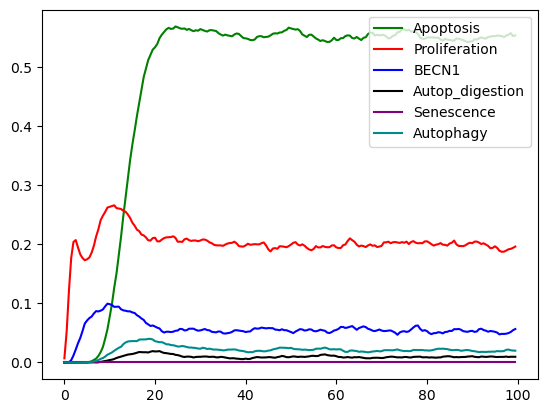

In [10]:
model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))
run_model_maboss = model_maboss.run()
run_model_maboss.plot_node_trajectory()

In [11]:
fp_table = run_model_maboss.get_fptable()
print(fp_table)


None


In [12]:
# For all nodes of the network, set the initial state to random
for n in model_maboss.network:
    model_maboss.network.set_istate(n,[0.5,0.5])

#InputsOFF = ["O_stress", "Growth_factor", "Glucose_starv", "AA_Starvation", "TNF_R_or_DR", "Insuline"]
#for node in InputsOFF:
#    model_maboss.network.set_istate(node, [1, 0])
    
WT_allinputs = model_maboss.copy()

WT_allinputs.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))
#WT_allinputs.network.set_output(("O_stress", "Growth_factor", "Glucose_starv", "AA_Starvation", "TNF_R_or_DR", "Insuline")
run_WT_allinputs = WT_allinputs.run()

WT_allinputs.palette = phenotypes_colors

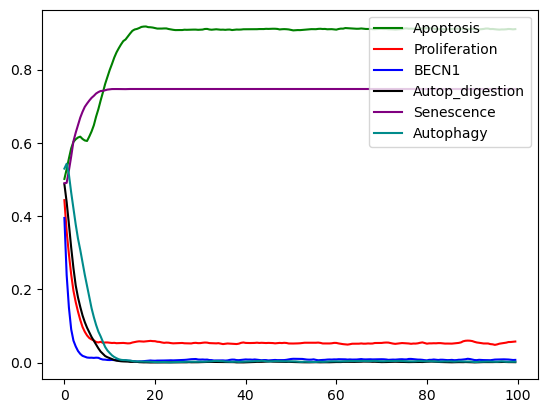

In [13]:
run_WT_allinputs.plot_node_trajectory()

Conclusion: this section shows that there is indeed a big limit cycle (or several limit cycles) that lead to apoptosis. What we see with the stable states of the Boolean model does not necessarily means that there exists only one phenotypic outcome with this model and the different contexts it simulates

## 5. Fixed point analysis

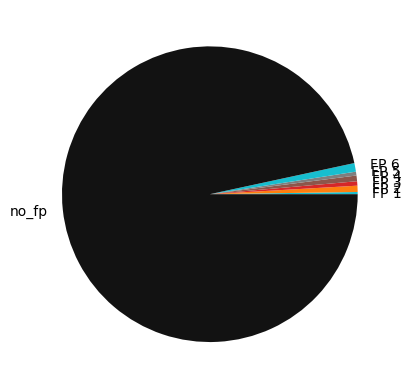

In [14]:
run_WT_allinputs.plot_fixpoint()

In [15]:
run_WT_allinputs.get_last_nodes_probtraj()


,Apoptosis,Autop_digestion,Autophagy,BECN1,Proliferation,Senescence
99.5000,0.910485,0.001208,0.002422,0.007398,0.057575,0.747


In [16]:
run_WT_allinputs.get_last_states_probtraj()

,<nil>,Apoptosis,Apoptosis -- Autop_digestion -- Senescence -- Autophagy,Apoptosis -- Autophagy,Apoptosis -- BECN1 -- Senescence,Apoptosis -- Proliferation,Apoptosis -- Proliferation -- Autophagy,Apoptosis -- Senescence,Autop_digestion -- Senescence -- Autophagy,Autophagy,BECN1,BECN1 -- Senescence,Proliferation,Senescence,Senescence -- Autophagy
99.5000,0.008882,0.185241,0.0004,0.000036,0.000075,0.020641,0.0002,0.703892,0.000808,0.000164,0.001102,0.006221,0.036734,0.03479,0.000814


In [17]:
fp_table = run_WT_allinputs.get_fptable()
print(fp_table)

   FP   Proba                                              State  \
0  #1  0.0024  EIF4E -- Cell_cycle -- Proliferation -- Growth...   
1  #2  0.0068  EIF4E -- Cell_cycle -- Proliferation -- Growth...   
2  #3  0.0048  EIF4E -- Cell_cycle -- Proliferation -- Growth...   
3  #4  0.0062  EIF4E -- Cell_cycle -- Proliferation -- Growth...   
4  #5  0.0042  EIF4E -- Cell_cycle -- Proliferation -- Growth...   
5  #6  0.0094  EIF4E -- Cell_cycle -- Proliferation -- Growth...   

   Caspase_3_6_7_C  Apoptosis  EIF4E  Cell_cycle  Proliferation  O_stress  \
0                0          0      1           1              1         0   
1                0          0      1           1              1         0   
2                0          0      1           1              1         0   
3                0          0      1           1              1         0   
4                0          0      1           1              1         0   
5                0          0      1           1             

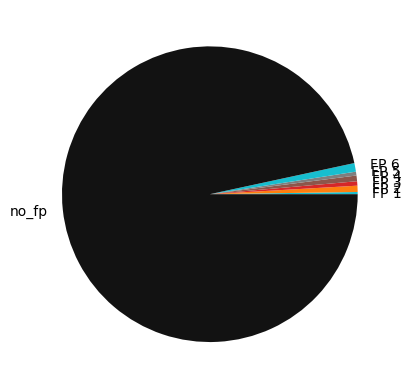

In [18]:
run_WT_allinputs.plot_fixpoint()

This section confirms the conclusion of the previous one.

**[2026-09-18 correction]** The scenario cells just below (Sections 6-8) build each run with `model_maboss.copy()`. Cell 19, just above, set every node's istate to random 0.5/0.5 on that same shared `model_maboss` object for the limit-cycle check -- which meant every scenario below was *unintentionally* inheriting that global randomization for inputs it never meant to touch (e.g. `O_stress` was left random, not OFF, even in the growth-factor-only scenario). The cell below rebuilds `model_maboss` explicitly and correctly instead: every node random, **except** the context-defining inputs (`BASE_INPUTS`), which are fixed -- each scenario cell's own `set_nodes_istate(...)` call then further fixes its specific input(s) on top of that.


In [19]:
model_maboss = biolqm.to_maboss(model_biolqm)
model_maboss.update_parameters(sample_count=5000, max_time=100, time_tick=0.5)
model_maboss.palette = phenotypes_colors

for n in model_maboss.network:
    model_maboss.network.set_istate(n, [0.5, 0.5])
for node, val in BASE_INPUTS.items():
    model_maboss.network.set_istate(node, [1 - val, val])


## 6. Simulate Four Scenarios and Visualize Outputs

The four classical stress scenarios validated against the literature:

| Scenario | Inputs set to ON |
|---|---|
| Growth-factor stimulation | `Growth_factor`, `Insuline` |
| Amino-acid starvation | `AA_Starvation` |
| ER stress / glucose starvation | `Glucose_starv` |
| Oxidative stress | `O_stress` |

For each, we track the full time-course probability of `Proliferation`, `Apoptosis` and `BECN1` to visualize the biphasic autophagy-then-apoptosis switch (or its absence, for the growth-factor scenario).

We additionally tested three scenarios with TNF or death receptor engagement that should trigger death. 

In [20]:
# 4 SCENARIOS with different initial conditions

GrowthFactorStimulation = {"Growth_factor": 1, "Insuline": 1}
AminoAcidStarvation = {"AA_Starvation": 1}
ERstressGlucoseStarvation = {"Glucose_starv": 1}
OxidativeStress = {"O_stress": 1}


Text(0.5, 0.98, 'WT simulations for the GF stimulation')

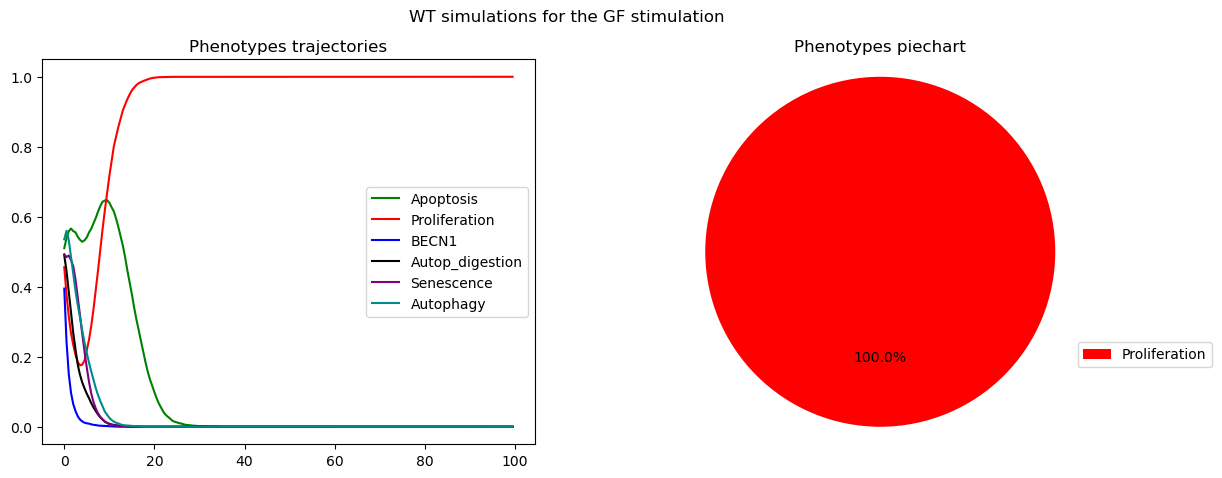

In [21]:
# SCENARIO 1

model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))
#model_maboss.network.set_output(("O_stress", "Growth_factor", "Glucose_starv", "AA_Starvation", "TNF_R_or_DR", "Insuline"))

WT_GF = model_maboss.copy()
maboss.set_nodes_istate(WT_GF, GrowthFactorStimulation, [0,1])
run_WT_GF = WT_GF.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_GF.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_GF.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the GF stimulation")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')


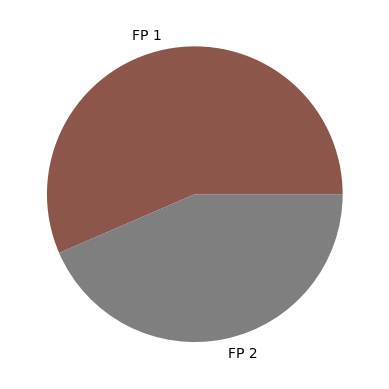

In [22]:
run_WT_GF.plot_fixpoint()

Text(0.5, 0.98, 'WT simulations for the AA starvation')

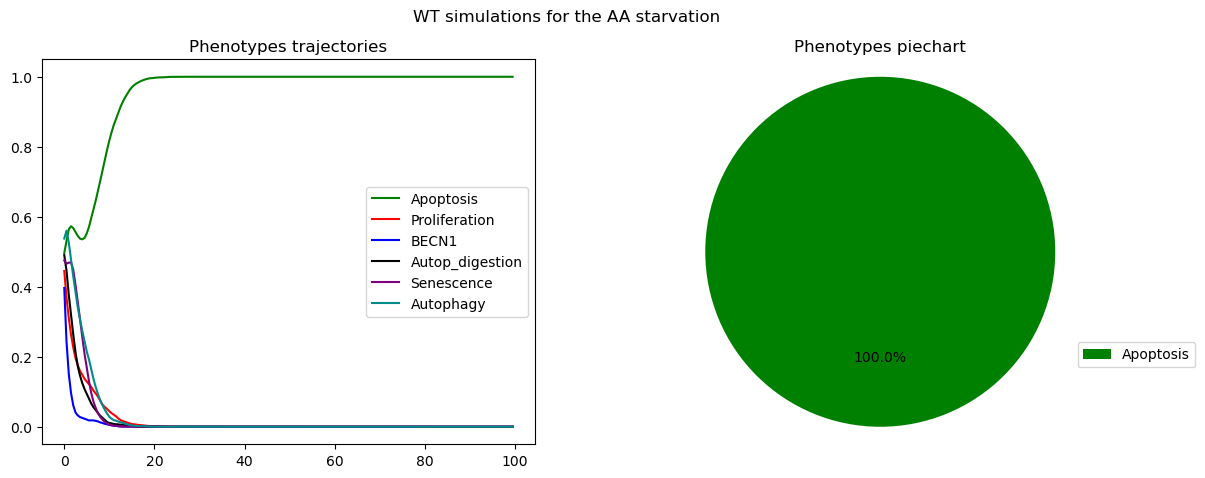

In [23]:
# SCENARIO 2

GrowthFactorStimulation = {"Growth_factor": 1, "Insuline": 1}
AminoAcidStarvation = {"AA_Starvation": 1}
ERstressGlucoseStarvation = {"Glucose_starv": 1}
OxidativeStress = {"O_stress": 1}

model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_AA = model_maboss.copy()
maboss.set_nodes_istate(WT_AA, AminoAcidStarvation, [0,1])
run_WT_AA = WT_AA.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_AA.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_AA.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the AA starvation")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')


In [24]:
#run_WT_AA.plot_fixpoint()

Text(0.5, 0.98, 'WT simulations for the ER starvation')

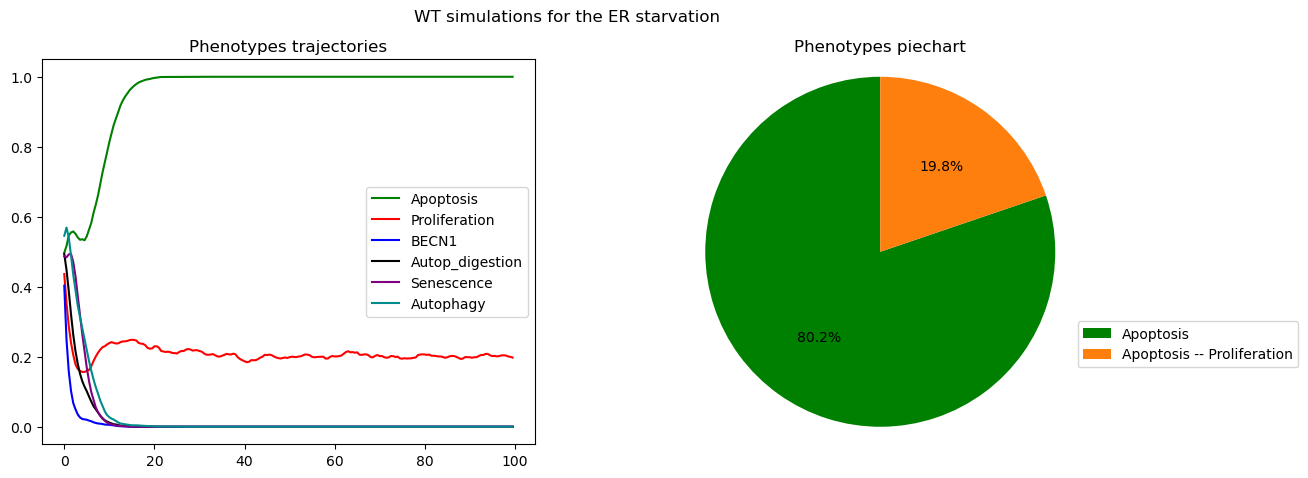

In [25]:
# SCENARIO 3

GrowthFactorStimulation = {"Growth_factor": 1, "Insuline": 1}
AminoAcidStarvation = {"AA_Starvation": 1}
ERstressGlucoseStarvation = {"Glucose_starv": 1}
OxidativeStress = {"O_stress": 1}

model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_ER = model_maboss.copy()
maboss.set_nodes_istate(WT_ER, ERstressGlucoseStarvation, [0,1])
run_WT_ER = WT_ER.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_ER.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_ER.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the ER starvation")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')


In [26]:
#run_WT_ER.plot_fixpoint()

Text(0.5, 0.98, 'WT simulations for the OS')

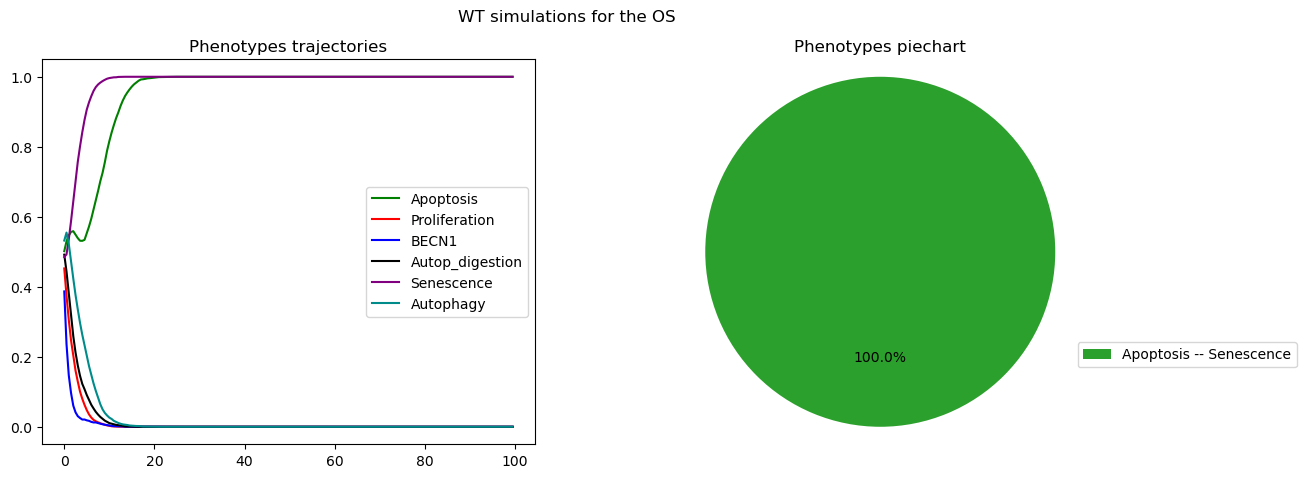

In [27]:
# SCENARIO 4

GrowthFactorStimulation = {"Growth_factor": 1, "Insuline": 1}
AminoAcidStarvation = {"AA_Starvation": 1}
ERstressGlucoseStarvation = {"Glucose_starv": 1}
OxidativeStress = {"O_stress": 1}

model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_OS = model_maboss.copy()
maboss.set_nodes_istate(WT_OS, OxidativeStress, [0,1])
run_WT_OS = WT_OS.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_OS.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_OS.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the OS")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')

Text(0.5, 0.98, 'WT simulations for the TNF')

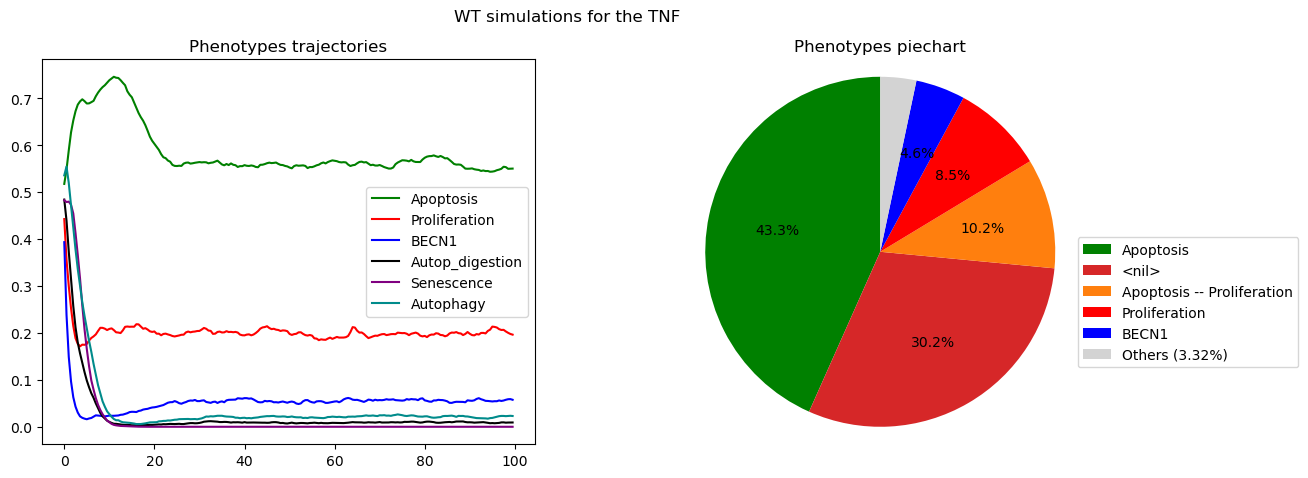

In [28]:
# SCENARIO 5
# expected outcome: Isolated TNF signaling is pro-survival (NF-κB) unless co-stimulated (Micheau & Tschopp 2003)

TNF_death = {"TNF_R_or_DR": 1}
TNF_OS = {"TNF_R_or_DR": 1, "O_stress": 1}
SevereConditions = {"Glucose_starv": 1, "O_stress": 1, "AA_Starvation": 1}


model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_TNF = model_maboss.copy()
maboss.set_nodes_istate(WT_TNF, TNF_death, [0,1])
run_WT_TNF = WT_TNF.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_TNF.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_TNF.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the TNF")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')

In [29]:
#run_WT_TNF.plot_fixpoint()

Text(0.5, 0.98, 'WT simulations for the TNF & oxidative stress')

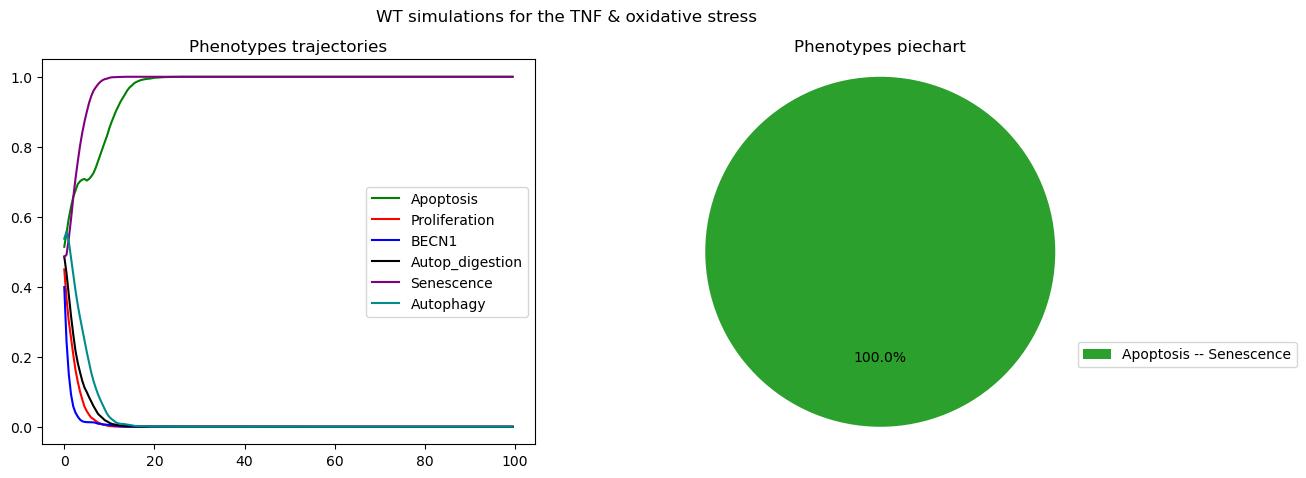

In [30]:
# SCENARIO 6
# expected outcome: Combined insults (“second hit”) switch outcome to death

TNF_death = {"TNF_R_or_DR": 1}
TNF_OS = {"TNF_R_or_DR": 1, "O_stress": 1}
SevereConditions = {"Glucose_starv": 1, "O_stress": 1, "AA_Starvation": 1}


model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_TNF_OS = model_maboss.copy()
maboss.set_nodes_istate(WT_TNF_OS, TNF_OS, [0,1])
run_WT_TNF_OS = WT_TNF_OS.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_TNF_OS.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_TNF_OS.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the TNF & oxidative stress")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')

Text(0.5, 0.98, 'WT simulations for the SC')

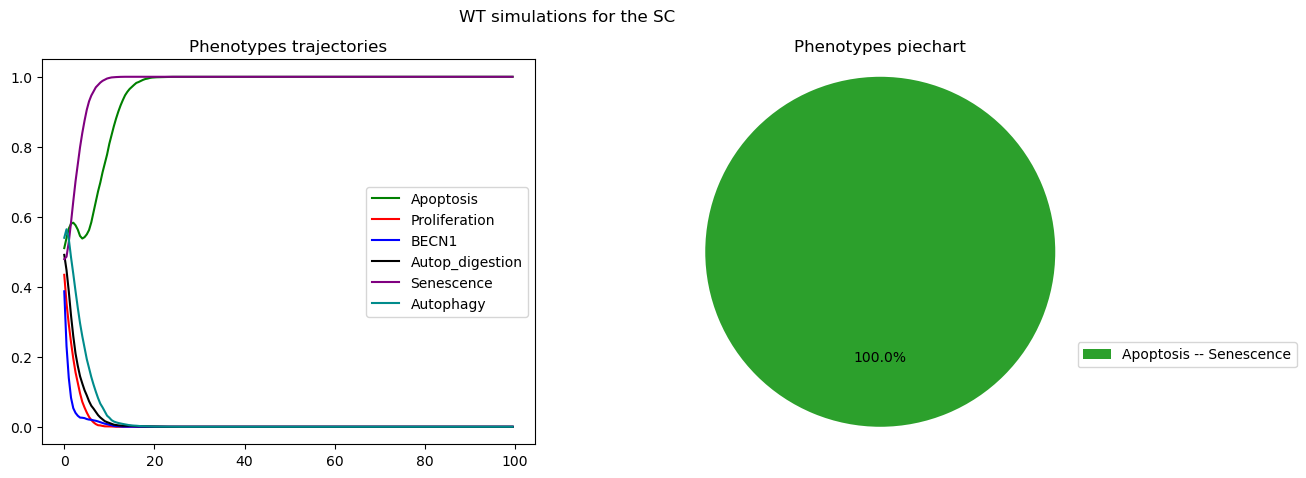

In [31]:
# SCENARIO 7
# expected outcome: Multiple concurrent stresses overwhelm adaptive capacity → death

TNF_death = {"TNF_R_or_DR": 1}
TNF_OS = {"TNF_R_or_DR": 1, "O_stress": 1}
SevereConditions = {"Glucose_starv": 1, "O_stress": 1, "AA_Starvation": 1}


model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_SC = model_maboss.copy()
maboss.set_nodes_istate(WT_SC, SevereConditions, [0,1])
run_WT_SC = WT_SC.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_SC.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_SC.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the SC")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')

## 7. Simulate `BECN1` Mutations (ON / OFF)

`BECN1` (Beclin1) is hypothesized to act as the death/survival switch. We force it permanently `ON` or `OFF` (`simulate_mutation`-equivalent via `copy_and_mutate`) on top of each of the four scenarios above, and compare the final `Apoptosis` / `Proliferation` / `Autop_digestion` probabilities to the wild-type (free `BECN1`) run.

Text(0.5, 0.98, 'BECN1 KO simulations')

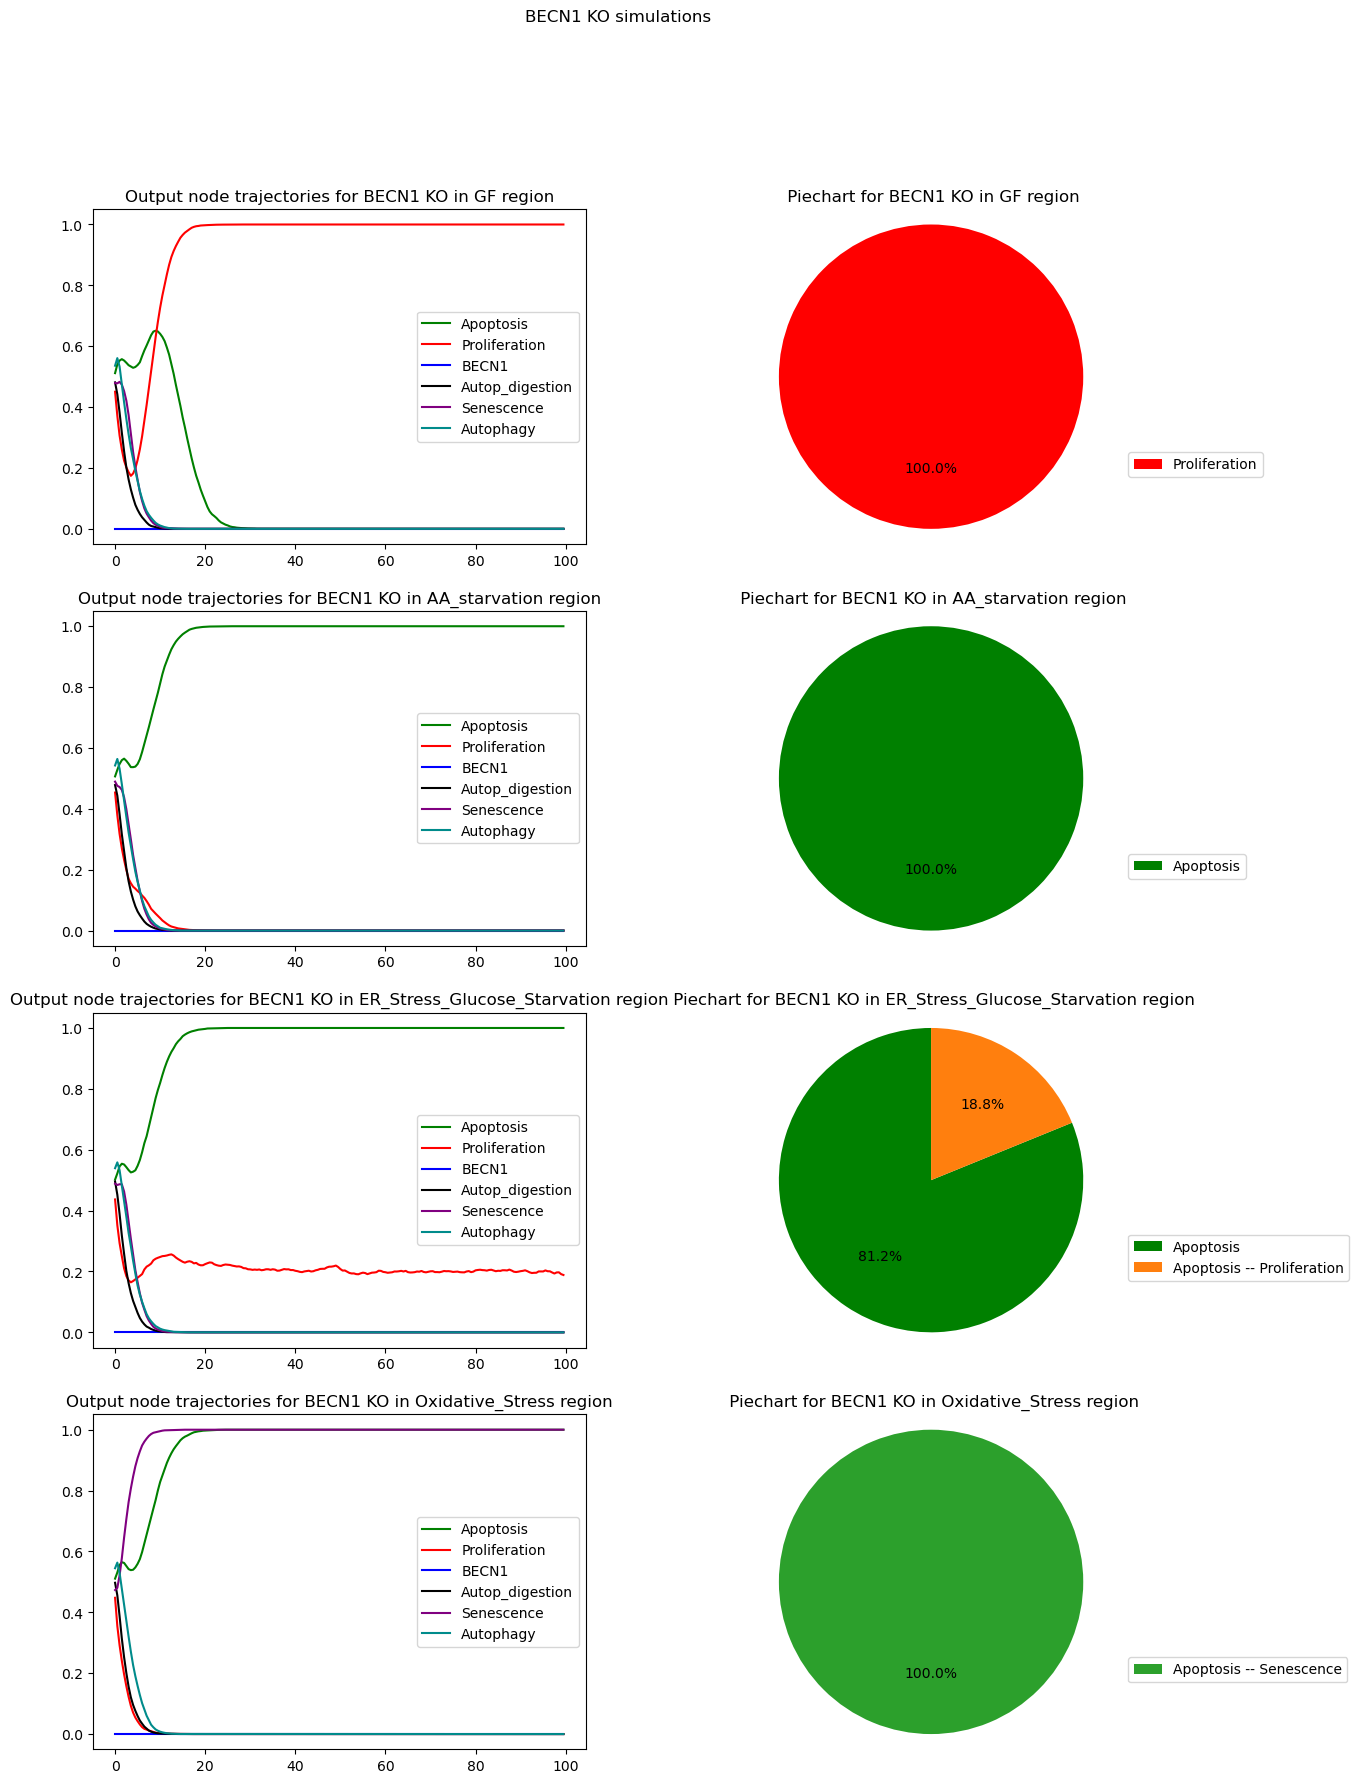

In [32]:
# Setting a figure encompassing four panels: with time plots and pie charts side by side,
# and the results for the four region input combinations over four rows.
fig, axes = plt.subplots(4,2, figsize=(14,20))
figrow=0  # integer for the iteration over the four regions (rows)
regions=['GF','AA_starvation','ER_Stress_Glucose_Starvation','Oxidative_Stress']

for init in [GrowthFactorStimulation,AminoAcidStarvation,ERstressGlucoseStarvation,OxidativeStress]:
    BECN1_KO_maboss = model_maboss.copy()
    BECN1_KO_maboss.mutate("BECN1", "OFF")
    maboss.set_nodes_istate(BECN1_KO_maboss, init, [0,1])
    BECN1_KO = BECN1_KO_maboss.run()
    BECN1_KO.plot_node_trajectory(axes=axes[figrow,0])
    axes[figrow,0].set_title(f"Output node trajectories for BECN1 KO in {regions[figrow]} region")
    BECN1_KO.plot_piechart(axes=axes[figrow,1])
    axes[figrow,1].set_title(f" Piechart for BECN1 KO in {regions[figrow]} region")
    figrow+=1

plt.suptitle("BECN1 KO simulations")


Text(0.5, 0.98, 'BECN1 KI simulations')

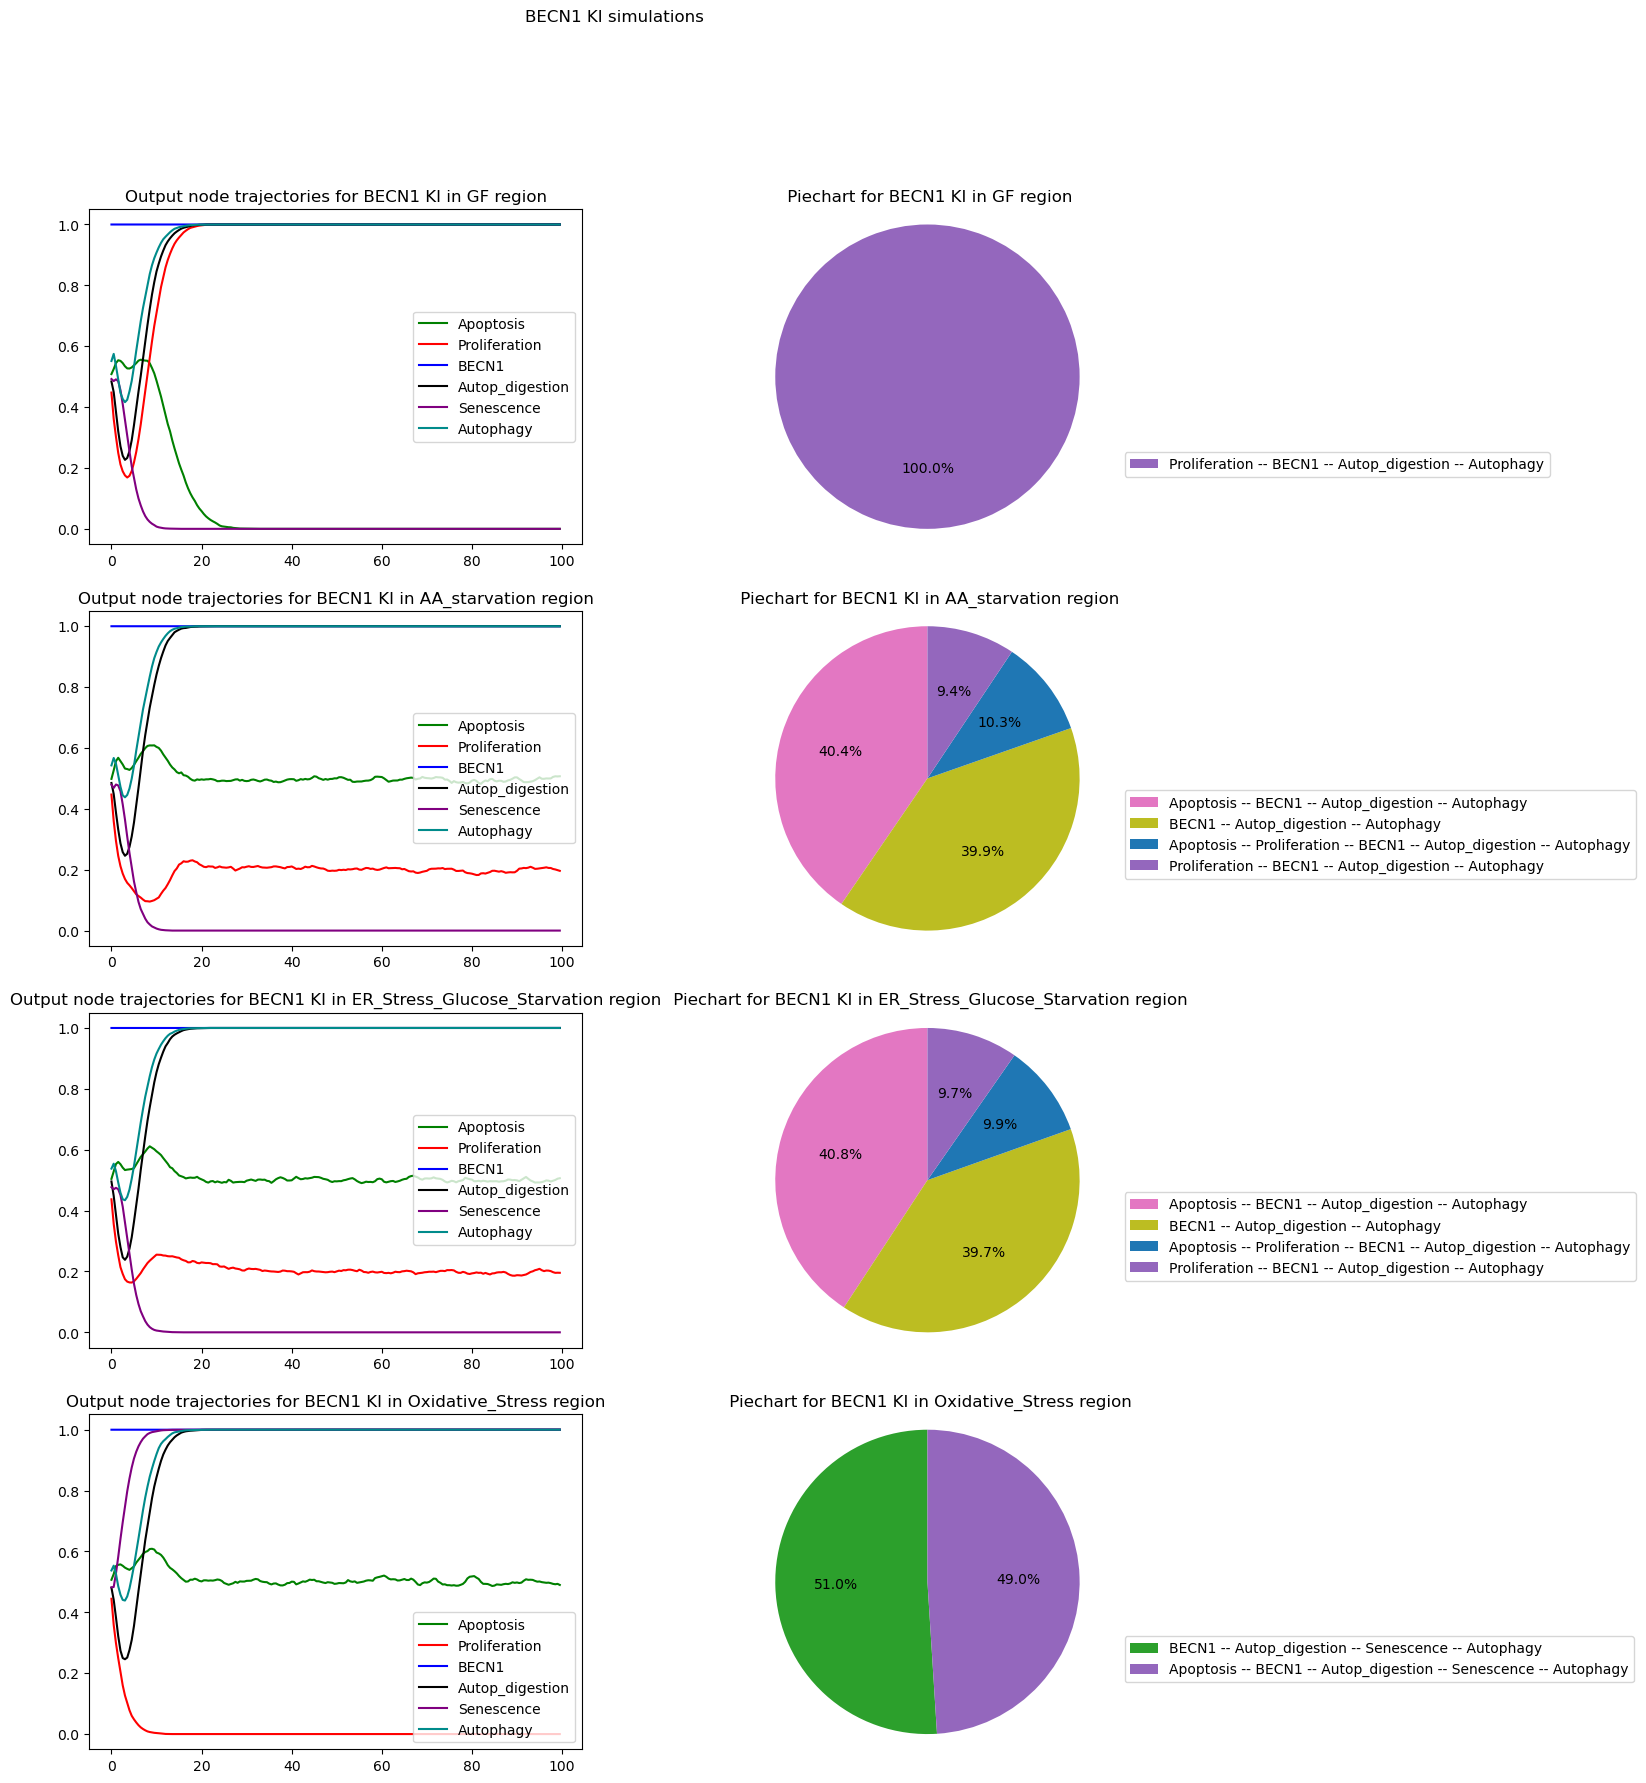

In [33]:
# Setting a figure encompassing four panels: with time plots and pie charts side by side,
# and the results for the four region input combinations over four rows.
fig, axes = plt.subplots(4,2, figsize=(14,20))
figrow=0  # integer for the iteration over the four regions (rows)
regions=['GF','AA_starvation','ER_Stress_Glucose_Starvation','Oxidative_Stress']

for init in [GrowthFactorStimulation,AminoAcidStarvation,ERstressGlucoseStarvation,OxidativeStress]:
    BECN1_KI_maboss = model_maboss.copy()
    BECN1_KI_maboss.mutate("BECN1", "ON")
    maboss.set_nodes_istate(BECN1_KI_maboss, init, [0,1])
    BECN1_KI = BECN1_KI_maboss.run()
    BECN1_KI.plot_node_trajectory(axes=axes[figrow,0])
    axes[figrow,0].set_title(f"Output node trajectories for BECN1 KI in {regions[figrow]} region")
    BECN1_KI.plot_piechart(axes=axes[figrow,1])
    axes[figrow,1].set_title(f" Piechart for BECN1 KI in {regions[figrow]} region")
    figrow+=1

plt.suptitle("BECN1 KI simulations")


BECN1 OFF has no impact. However, forcing BECN1 to be active switches the phenotype towards an autphagy one. 

## 8. Simulate mTOR treatment (rapamycin)

Text(0.5, 0.98, 'mTOR KO simulations')

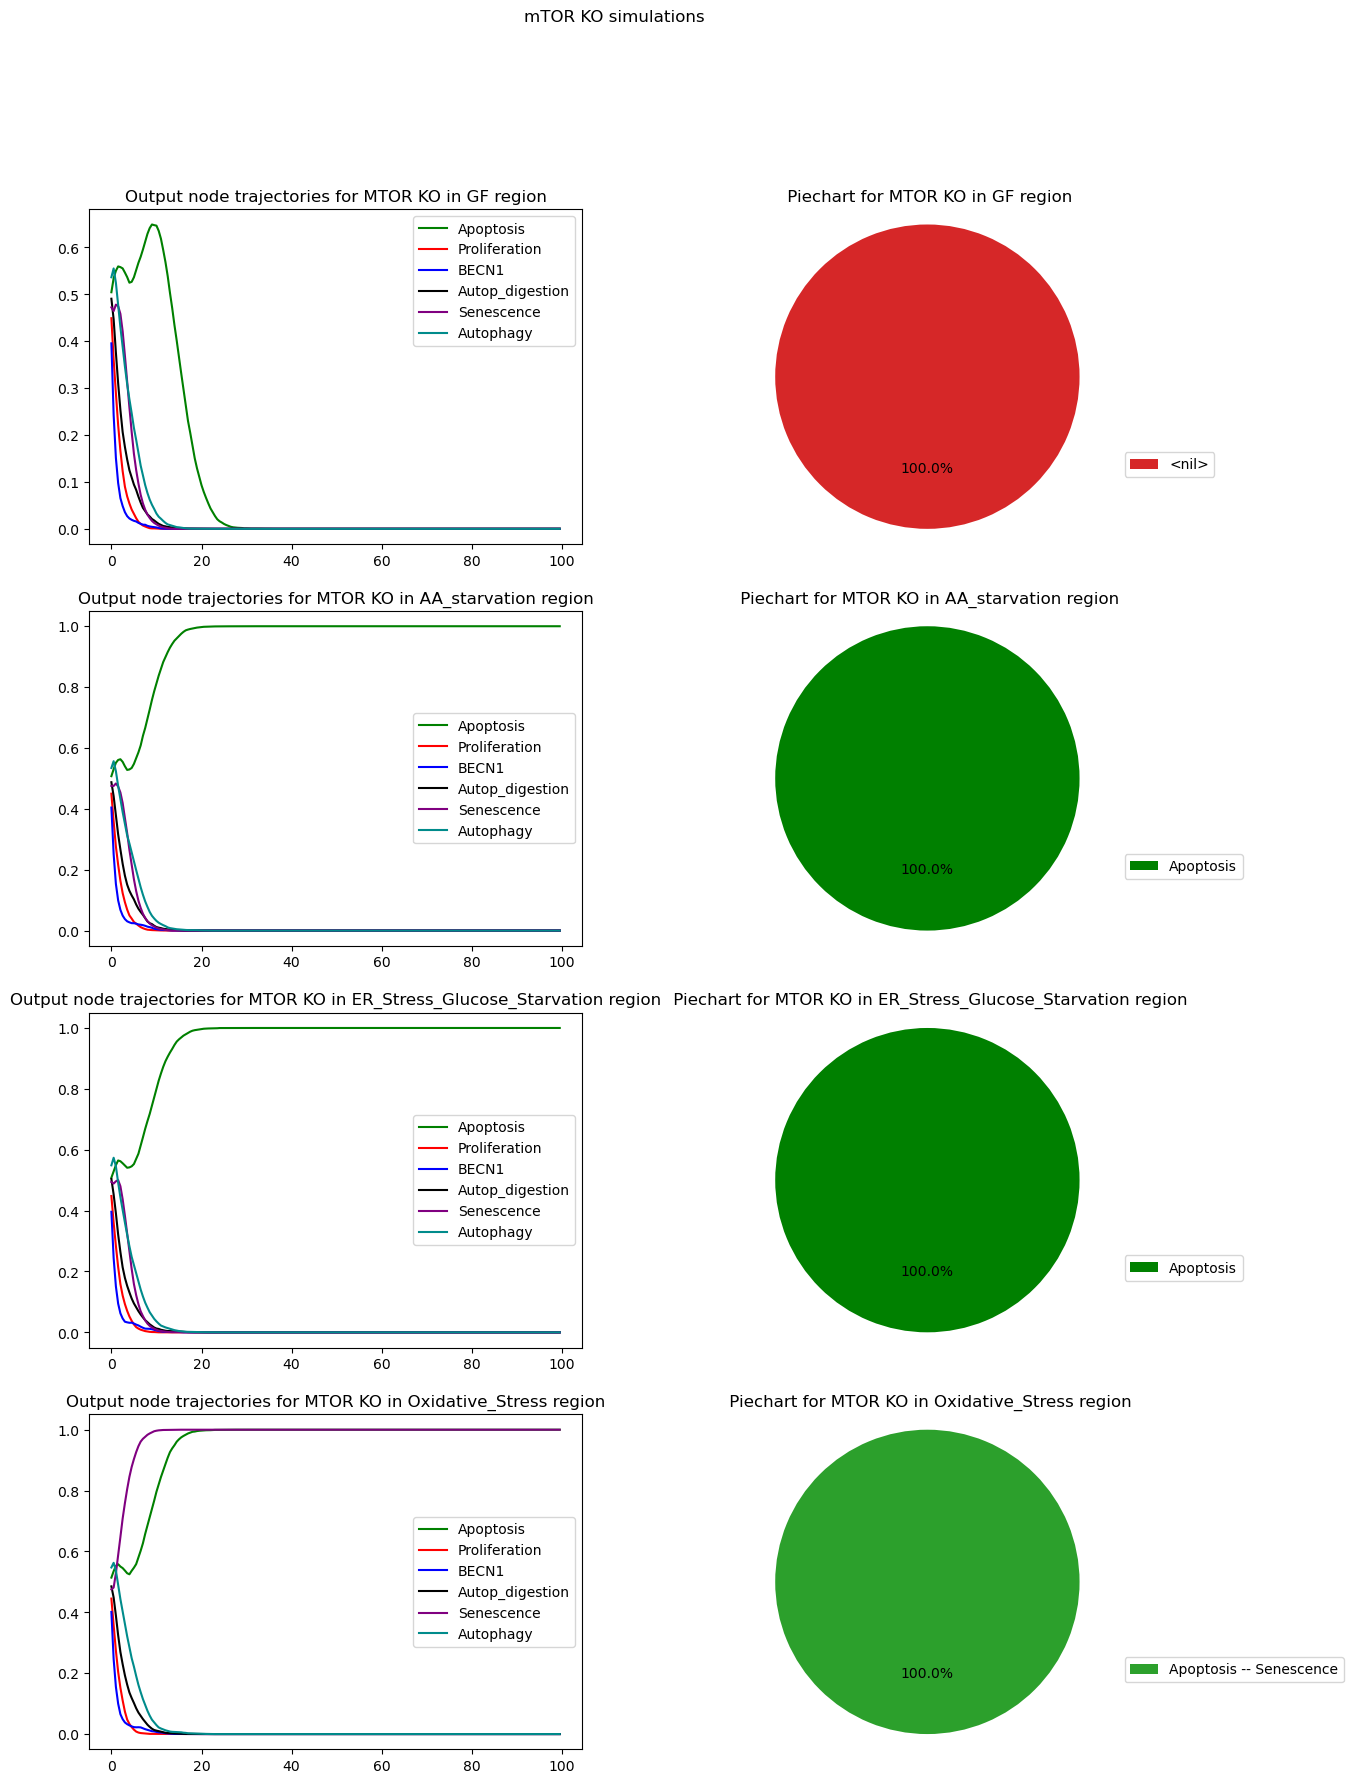

In [34]:
# Setting a figure encompassing four panels: with time plots and pie charts side by side,
# and the results for the four region input combinations over four rows.
fig, axes = plt.subplots(4,2, figsize=(14,20))
figrow=0  # integer for the iteration over the four regions (rows)
regions=['GF','AA_starvation','ER_Stress_Glucose_Starvation','Oxidative_Stress']

for init in [GrowthFactorStimulation,AminoAcidStarvation,ERstressGlucoseStarvation,OxidativeStress]:
    MTOR_KO_maboss = model_maboss.copy()
    MTOR_KO_maboss.mutate("MTOR", "OFF")
    maboss.set_nodes_istate(MTOR_KO_maboss, init, [0,1])
    MTOR_KO = MTOR_KO_maboss.run()
    MTOR_KO.plot_node_trajectory(axes=axes[figrow,0])
    axes[figrow,0].set_title(f"Output node trajectories for MTOR KO in {regions[figrow]} region")
    MTOR_KO.plot_piechart(axes=axes[figrow,1])
    axes[figrow,1].set_title(f" Piechart for MTOR KO in {regions[figrow]} region")
    figrow+=1

plt.suptitle("mTOR KO simulations")


Conclusion: mTOR inhibition leads to a full apoptotic phenotype

## 9. Compare Mutation Results Across Scenarios

Grouped bar charts of final `Apoptosis` and `Proliferation` probability, for WT / `BECN1`-ON / `BECN1`-OFF, in each of the four scenarios.

In [35]:
# [2026-09-18] Cleaned up: this cell used to contain two conflicting definitions of
# make_simulation. Only the second one was ever actually in effect (Python keeps the
# last definition of a name in a cell), and it already randomized every node before
# fixing the inputs -- kept and clarified below, duplicate removed.
SCENARIOS = {
    "Growth-factor stimulation": {"Growth_factor": 1, "Insuline": 1},
    "Amino-acid starvation": {"AA_Starvation": 1},
    "ER stress / glucose starvation": {"Glucose_starv": 1},
    "Oxidative stress": {"O_stress": 1},
}

def make_simulation(overrides=None, max_time=60, sample_count=3000, time_tick=0.5):
    """Fresh simulation: every node starts random (0.5/0.5) EXCEPT the context-defining
    inputs (BASE_INPUTS, plus any scenario-specific overrides), which are fixed
    deterministically -- these are "the inputs that correspond to different contexts"."""
    sim = biolqm.to_maboss(model_biolqm)
    sim.update_parameters(max_time=max_time, sample_count=sample_count, time_tick=time_tick, thread_count=4)
    for n in sim.network:
        sim.network.set_istate(n, [0.5, 0.5])
    inputs = dict(BASE_INPUTS)
    if overrides:
        inputs.update(overrides)
    for node, val in inputs.items():
        sim.network.set_istate(node, [1 - val, val])
    sim.network.set_output(OUTPUT_NODES)
    return sim


def run_mutant(overrides, mutation, max_time=60, sample_count=2000):
    """mutation: 'WT' (free BECN1), 'ON' (locked) or 'OFF' (knocked out)."""
    sim = make_simulation(overrides, max_time=max_time, sample_count=sample_count)
    if mutation in ("ON", "OFF"):
        sim.mutate("BECN1", mutation)
    res = sim.run()
    last = res.get_last_nodes_probtraj().iloc[0]
    return last.reindex(OUTPUT_NODES).fillna(0.0)


mutation_results = {}
for name, overrides in SCENARIOS.items():
    for mutation in ["WT", "ON", "OFF"]:
        mutation_results[(name, mutation)] = run_mutant(overrides, mutation)

mutation_df = pd.DataFrame(mutation_results).T
mutation_df.index.names = ["scenario", "BECN1 mutation"]
mutation_df


Apoptosis  Proliferation  \
scenario                       BECN1 mutation                             
Growth-factor stimulation      WT               0.000000       1.000000   
                               ON               0.000000       1.000000   
                               OFF              0.000000       1.000000   
Amino-acid starvation          WT               1.000000       0.000000   
                               ON               0.476389       0.191090   
                               OFF              1.000000       0.000000   
ER stress / glucose starvation WT               1.000000       0.196691   
                               ON               0.493156       0.207058   
                               OFF              1.000000       0.194810   
Oxidative stress               WT               1.000000       0.000000   
                               ON               0.508928       0.000000   
                               OFF              1.000000       0.000000   

                                                  BECN1  Autop_digestion  \
scenario                       BECN1 mutation                              
Growth-factor stimulation      WT              0.000000         0.000000   
                               ON              1.000000         1.000000   
                               OFF             0.000000         0.000000   
Amino-acid starvation          WT              0.000000         0.000000   
                               ON              1.000000         1.000000   
                               OFF             0.000000         0.000000   
ER stress / glucose starvation WT              0.000000         0.000000   
                               ON              0.999999         0.999999   
                               OFF             0.000000         0.000000   
Oxidative stress               WT              0.000000         0.000000   
                               ON              1.000000         1.000000   
                               OFF             0.000000         0.000000   

                                               Autophagy  Senescence  SQSTM1  
scenario                       BECN1 mutation                                 
Growth-factor stimulation      WT               0.000000         0.0     1.0  
                               ON               1.000000         0.0     0.0  
                               OFF              0.000000         0.0     1.0  
Amino-acid starvation          WT               0.000000         0.0     1.0  
                               ON               1.000000         0.0     0.0  
                               OFF              0.000000         0.0     1.0  
ER stress / glucose starvation WT               0.000000         0.0     1.0  
                               ON               0.999999         0.0     0.0  
                               OFF              0.000000         0.0     1.0  
Oxidative stress               WT               0.000000         1.0     1.0  
                               ON               1.000000         1.0     0.0  
                               OFF              0.000000         1.0     1.0

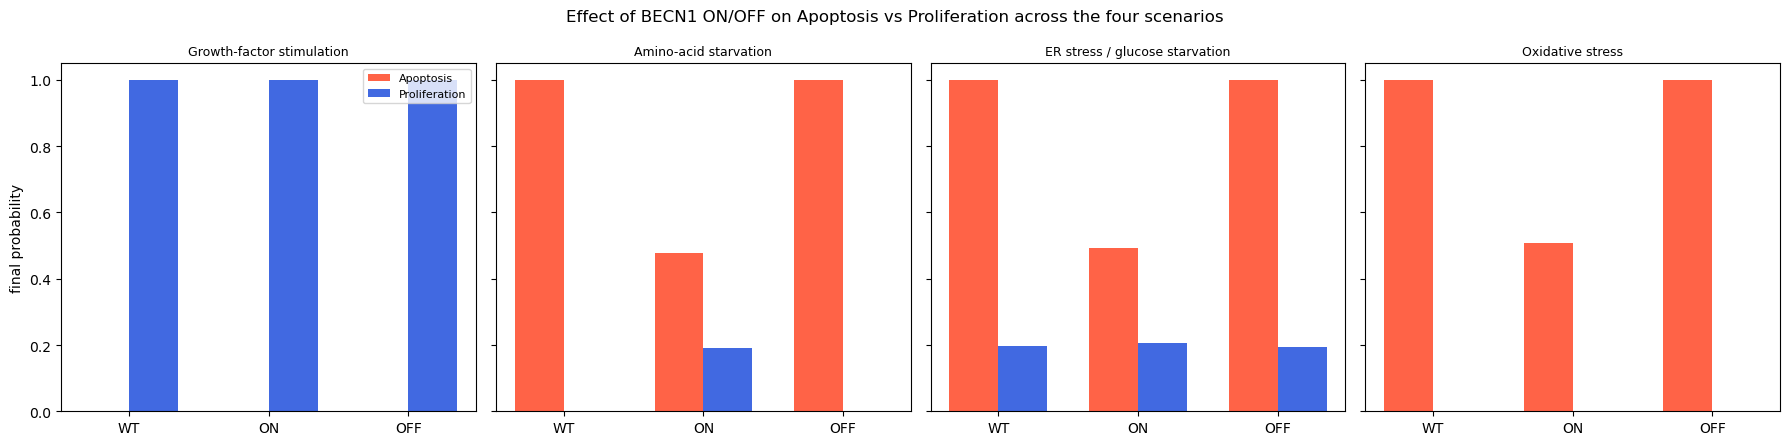

In [36]:
mutation_order = ["WT", "ON", "OFF"]
width = 0.35

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, name in zip(axes, SCENARIOS):
    sub = mutation_df.loc[name].loc[mutation_order]
    x = range(len(mutation_order))
    ax.bar([i - width / 2 for i in x], sub["Apoptosis"], width, label="Apoptosis", color="tomato")
    ax.bar([i + width / 2 for i in x], sub["Proliferation"], width, label="Proliferation", color="royalblue")
    ax.set_xticks(list(x))
    ax.set_xticklabels(mutation_order)
    ax.set_title(name, fontsize=9)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("final probability")
axes[0].legend(fontsize=8)
plt.suptitle("Effect of BECN1 ON/OFF on Apoptosis vs Proliferation across the four scenarios")
plt.tight_layout()
plt.show()


In [37]:
mutation_results = {}
for name, overrides in SCENARIOS.items():
    for mutation in ["WT", "OFF"]:
        mutation_results[(name, mutation)] = run_mutant(overrides, mutation)

mutation_df = pd.DataFrame(mutation_results).T
mutation_df.index.names = ["scenario", "MTOR mutation"]
mutation_df
SCENARIOS = {
    "Growth-factor stimulation": {"Growth_factor": 1, "Insuline": 1},
    "Amino-acid starvation": {"AA_Starvation": 1},
    "ER stress / glucose starvation": {"Glucose_starv": 1},
    "Oxidative stress": {"O_stress": 1},
}

def run_mutant(overrides, mutation, max_time=60, sample_count=2000):
    """mutation: 'WT', 'OFF' (knocked out)."""
    sim = make_simulation(overrides, max_time=max_time, sample_count=sample_count)
    if mutation in ("OFF"):
        sim.mutate("MTOR", mutation)
    res = sim.run()
    last = res.get_last_nodes_probtraj().iloc[0]
    return last.reindex(OUTPUT_NODES).fillna(0.0)


mutation_results = {}
for name, overrides in SCENARIOS.items():
    for mutation in ["WT", "OFF"]:
        mutation_results[(name, mutation)] = run_mutant(overrides, mutation)

mutation_df = pd.DataFrame(mutation_results).T
mutation_df.index.names = ["scenario", "mTOR mutation"]
mutation_df


Apoptosis  Proliferation  BECN1  \
scenario                       mTOR mutation                                    
Growth-factor stimulation      WT                   0.0       1.000000    0.0   
                               OFF                  0.0       0.000000    0.0   
Amino-acid starvation          WT                   1.0       0.000000    0.0   
                               OFF                  1.0       0.000000    0.0   
ER stress / glucose starvation WT                   1.0       0.214828    0.0   
                               OFF                  1.0       0.000000    0.0   
Oxidative stress               WT                   1.0       0.000000    0.0   
                               OFF                  1.0       0.000000    0.0   

                                              Autop_digestion  Autophagy  \
scenario                       mTOR mutation                               
Growth-factor stimulation      WT                         0.0        0.0   
                               OFF                        0.0        0.0   
Amino-acid starvation          WT                         0.0        0.0   
                               OFF                        0.0        0.0   
ER stress / glucose starvation WT                         0.0        0.0   
                               OFF                        0.0        0.0   
Oxidative stress               WT                         0.0        0.0   
                               OFF                        0.0        0.0   

                                              Senescence  SQSTM1  
scenario                       mTOR mutation                      
Growth-factor stimulation      WT                    0.0     1.0  
                               OFF                   0.0     1.0  
Amino-acid starvation          WT                    0.0     1.0  
                               OFF                   0.0     1.0  
ER stress / glucose starvation WT                    0.0     1.0  
                               OFF                   0.0     1.0  
Oxidative stress               WT                    1.0     1.0  
                               OFF                   1.0     1.0

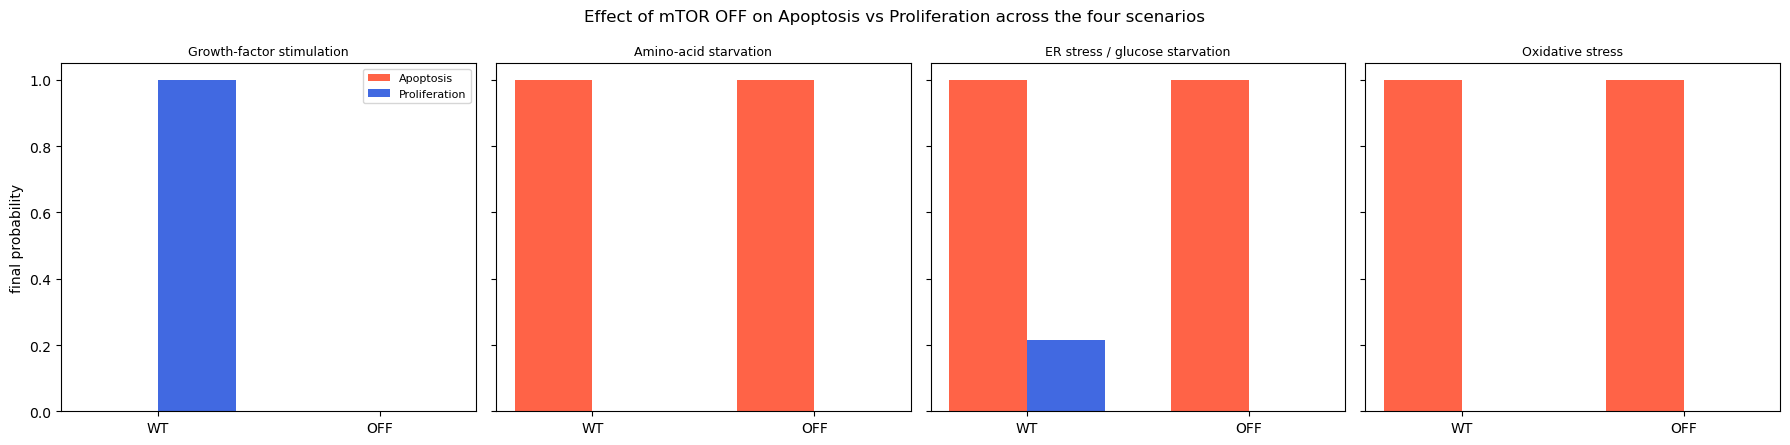

In [38]:
mutation_order = ["WT", "OFF"]
width = 0.35

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, name in zip(axes, SCENARIOS):
    sub = mutation_df.loc[name].loc[mutation_order]
    x = range(len(mutation_order))
    ax.bar([i - width / 2 for i in x], sub["Apoptosis"], width, label="Apoptosis", color="tomato")
    ax.bar([i + width / 2 for i in x], sub["Proliferation"], width, label="Proliferation", color="royalblue")
    ax.set_xticks(list(x))
    ax.set_xticklabels(mutation_order)
    ax.set_title(name, fontsize=9)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("final probability")
axes[0].legend(fontsize=8)
plt.suptitle("Effect of mTOR OFF on Apoptosis vs Proliferation across the four scenarios")
plt.tight_layout()
plt.show()


Problem with this last figure ==> GF in mTOR OFF is fully apoptotic... 

## 9. Conclusion


A question that we need to address is what we see here is at the level of individual cells. We cannot conclude whether it is beneficial or not for cancer. However, we can start thinking about what would happen if we use a population of cells. Would some cells die for the benefit of the population? How many? 

## 10. Model extension: new phenotype markers and a genotoxic-stress input

The regulatory network (`.zginml`, `.bnd`/`.cfg`) was extended from 119 to 125 nodes. The 6 new nodes were added directly through the GINsim scripting API (not by hand-editing the XML, and not by round-tripping through bioLQM, which would have discarded the original file's literature annotations) and verified node-by-node: **only** the 6 additions below and 2 purely-additive logic changes exist relative to the original 119 nodes; every other node's formula is byte-for-byte identical, and all 214 PMID citation strings embedded in the original file are preserved (`Autophagy_and_apoptosis_Sept26.zginml.bak` keeps the pre-extension version, if you want to diff).

| Node | Logic | Rationale |
|---|---|---|
| `Autophagy` | `Atphgo_form \| Atphgo_mat` | Composite phenotype output, mirrored on `Apoptosis`/`Proliferation`: autophagy machinery engaged, from formation onward. Deliberately broader than `Autop_digestion`, which is currently logically identical to `Atphgo_mat` (a single-parent passthrough) — worth knowing if you were treating them as independent readouts. |
| `SQSTM1` | `!Autop_digestion` | p62/SQSTM1: the clinical/experimental readout that resolves whether LC3-II accumulation means active induction or a downstream flux block. Accumulates when degradation isn't happening, cleared once flux completes. |
| `DNA_damage` | input (like `O_stress`) | Genotoxic stress (chemo/radiotherapy), now separable from generic oxidative stress. |
| `ATM` (extended) | `O_stress \| DNA_damage` | Purely additive: the existing `O_stress` route is untouched, `DNA_damage` adds a second, independent trigger. |
| `CDKN2A` (p16INK4a) | `ATM` | Senescence marker, driven by persistent DNA-damage/oncogenic-stress signaling, largely independent of the p21/MDM2 arm (Kuilman 2010; Gorgoulis 2019). |
| `p21_sustained` | `p21` | Persistence proxy for p21, same pattern the model already uses for `CHOP_sustained`/`SP1_sustained`: distinguishes a durable p21 signal from a transient checkpoint blip. |
| `pRB` (extended) | `p21 \| CDKN2A` | Purely additive: adds the p16/RB senescence branch alongside the existing p21 branch. |
| `Senescence` | `(pRB & p21_sustained) \| (pRB & CDKN2A)` | Composite phenotype output, mirrored on `Apoptosis`/`Proliferation`/`Autophagy`: durable RB-mediated arrest, distinguished from a transient cell-cycle checkpoint by requiring a *sustained* driver. |

These are modeling judgment calls (SQSTM1's abstraction as a strict complement of flux, and the exact senescence logic in particular) — worth sanity-checking against how you'd want senescence commitment defined before treating `Senescence` results as final.

The GINsim diagram's logic and edges are updated, but the 6 new nodes don't yet have a curated canvas position (they'll appear, just need manual placement) — everything else in the diagram, including all layout and literature annotations for the original 119 nodes, is untouched.


In [39]:
# Sanity-check: the model now loaded from the updated .zginml carries the new nodes
new_markers = ["Autophagy", "Senescence", "SQSTM1", "DNA_damage", "CDKN2A", "p21_sustained"]
all_nodes = [str(n) for n in model_maboss.network]
print("Total nodes:", len(all_nodes))
print("New markers present:", {m: (m in all_nodes) for m in new_markers})


Total nodes: 126
New markers present: {'Autophagy': True, 'Senescence': True, 'SQSTM1': True, 'DNA_damage': True, 'CDKN2A': True, 'p21_sustained': True}


## 11. Early- vs. late-stage autophagy inhibition

Autophagy inhibitors used or trialled in oncology don't all act at the same step, and the difference matters clinically:
- **Early block** (3-methyladenine/wortmannin-like): `PIK3C3` (VPS34) OFF -- prevents autophagosome **nucleation** entirely.
- **Late block** (chloroquine/hydroxychloroquine-like): `RAB7A` OFF -- lets autophagosomes **form** but blocks fusion with the lysosome, so they accumulate undegraded.

**[2026-09-18 correction]** The original version of this section compared a single snapshot at `max_time=15`, chosen to land near a "peak" that only exists when every node starts at a deterministic zero (a synchronized, quiescent population stimulated at t=0). Now that `make_simulation()` starts every internal node random (an unsynchronized population), there is no such peak to aim for -- instead, the population's random initial noise simply decays away over the first ~20 time units, regardless of any drug. So this section now shows the **full decay trajectory** rather than one snapshot: the mechanistic distinction between the two drug classes shows up in *how fast* `Autophagy` decays to zero, not in a peak height.


In [40]:
autophagy_block_trajectories = {}
for label, mutation in [
    ("WT (no block)", None),
    ("Early block: PIK3C3-OFF", ("PIK3C3", "OFF")),
    ("Late/CQ-like block: RAB7A-OFF", ("RAB7A", "OFF")),
]:
    for scenario_name, overrides in SCENARIOS.items():
        sim = make_simulation(overrides, max_time=40, sample_count=2500, time_tick=1)
        if mutation:
            sim.mutate(*mutation)
        autophagy_block_trajectories[(scenario_name, label)] = sim.run().get_nodes_probtraj()


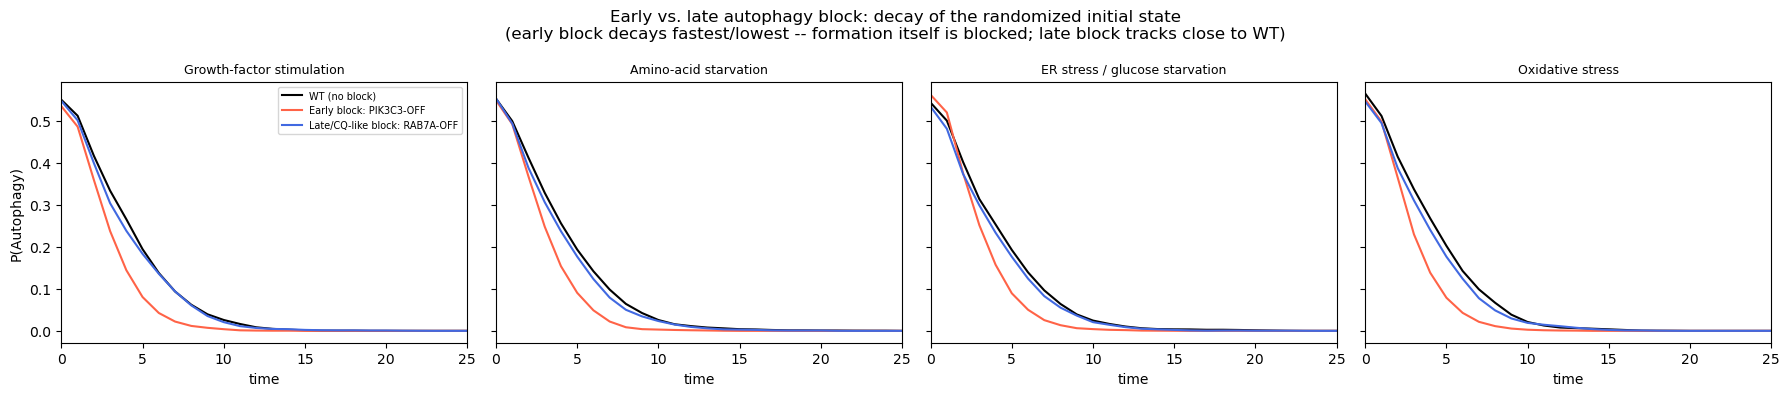

In [41]:
block_colors = {"WT (no block)": "black", "Early block: PIK3C3-OFF": "tomato", "Late/CQ-like block: RAB7A-OFF": "royalblue"}
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, scenario_name in zip(axes, SCENARIOS):
    for label, color in block_colors.items():
        traj = autophagy_block_trajectories[(scenario_name, label)]
        ax.plot(traj.index, traj["Autophagy"], label=label, color=color)
    ax.set_xlim(0, 25)
    ax.set_title(scenario_name, fontsize=9)
    ax.set_xlabel("time")
axes[0].set_ylabel("P(Autophagy)")
axes[0].legend(fontsize=7)
plt.suptitle("Early vs. late autophagy block: decay of the randomized initial state\n(early block decays fastest/lowest -- formation itself is blocked; late block tracks close to WT)")
plt.tight_layout()
plt.show()


In [42]:
# Fully-settled endpoint (t=40): by now Autophagy is 0 for all three conditions in every
# scenario -- the early/late distinction is a transient-decay effect (plot above), not a
# steady-state one. Apoptosis, in contrast, DOES have a stable, non-transient endpoint,
# and confirms the earlier finding: blocking autophagy (either way) does not change it.
final_rows = {}
for label in block_colors:
    for scenario_name in SCENARIOS:
        last = autophagy_block_trajectories[(scenario_name, label)].iloc[-1]
        final_rows[(scenario_name, label)] = last.reindex(OUTPUT_NODES).fillna(0.0)
final_autophagy_block_df = pd.DataFrame(final_rows).T
final_autophagy_block_df.index.names = ["scenario", "block"]
final_autophagy_block_df[["Apoptosis", "Autophagy", "SQSTM1"]]


,,Apoptosis,Autophagy,SQSTM1
scenario,block,,,
Growth-factor stimulation,WT (no block),0.0,0.0,1.0
Amino-acid starvation,WT (no block),1.0,0.0,1.0
ER stress / glucose starvation,WT (no block),1.0,0.0,1.0
Oxidative stress,WT (no block),1.0,0.0,1.0
Growth-factor stimulation,Early block: PIK3C3-OFF,0.0,0.0,1.0
Amino-acid starvation,Early block: PIK3C3-OFF,1.0,0.0,1.0
ER stress / glucose starvation,Early block: PIK3C3-OFF,1.0,0.0,1.0
Oxidative stress,Early block: PIK3C3-OFF,1.0,0.0,1.0
Growth-factor stimulation,Late/CQ-like block: RAB7A-OFF,0.0,0.0,1.0


Conclusion: Early block drives Autophagy to exactly 0 in every stress scenario (nucleation genuinely abolished), while late block leaves Autophagy essentially at the WT level (autophagosomes still form, only fusion is blocked) — that's exactly the qualitative signature seen experimentally (3-MA/VPS34i reduce LC3 punctae; CQ/HCQ cause them to accumulate). Meanwhile SQSTM1 saturates to ~1.0 under both blocks, also correctly — p62 accumulation doesn't care where the block is, only that flux doesn't complete. This is exactly why having both markers (not just one) was worth adding: Autophagy alone would have made early and late block look identical to a naive "is autophagy happening" question.

## 12. Oncogenic backgrounds under stress

Every scenario so far runs on a wild-type background. Real tumors carry recurrent lesions in exactly this network. Locking in a handful of the most common ones and re-running the 4 stress scenarios asks a more clinically relevant question: does a given oncogenic lesion **rescue** stressed cells from the autophagy-to-apoptosis switch, or does it just add proliferative drive on top of a fate the network still reaches?


In [38]:
ONCO_BACKGROUNDS = {
    "WT": {},
    "PTEN-OFF (PI3K/AKT hyperactive)": {"PTEN": "OFF"},
    "PIK3CA-ON (constitutive)": {"PIK3CA": "ON"},
    "TP53_nuc-OFF (p53 loss)": {"TP53_nuc": "OFF"},
    "MYC-ON (overexpression)": {"MYC": "ON"},
    "BCL2-ON (overexpression)": {"BCL2": "ON"},
}

onco_results = {}
for scenario_name, overrides in SCENARIOS.items():
    for onco_name, mutations in ONCO_BACKGROUNDS.items():
        sim = make_simulation(overrides, max_time=60, sample_count=2000)
        for node, mut in mutations.items():
            sim.mutate(node, mut)
        res = sim.run()
        last = res.get_last_nodes_probtraj().iloc[0]
        onco_results[(scenario_name, onco_name)] = last.reindex(OUTPUT_NODES).fillna(0.0)

onco_df = pd.DataFrame(onco_results).T
onco_df.index.names = ["scenario", "oncogenic background"]
onco_df[["Apoptosis", "Proliferation", "Senescence"]]


Apoptosis  \
scenario                       oncogenic background                         
Growth-factor stimulation      WT                                     0.0   
                               PTEN-OFF (PI3K/AKT hyperactive)        0.0   
                               PIK3CA-ON (constitutive)               0.0   
                               TP53_nuc-OFF (p53 loss)                0.0   
                               MYC-ON (overexpression)                0.0   
                               BCL2-ON (overexpression)               0.0   
Amino-acid starvation          WT                                     1.0   
                               PTEN-OFF (PI3K/AKT hyperactive)        1.0   
                               PIK3CA-ON (constitutive)               1.0   
                               TP53_nuc-OFF (p53 loss)                1.0   
                               MYC-ON (overexpression)                1.0   
                               BCL2-ON (overexpression)               0.0   
ER stress / glucose starvation WT                                     1.0   
                               PTEN-OFF (PI3K/AKT hyperactive)        1.0   
                               PIK3CA-ON (constitutive)               1.0   
                               TP53_nuc-OFF (p53 loss)                1.0   
                               MYC-ON (overexpression)                1.0   
                               BCL2-ON (overexpression)               0.0   
Oxidative stress               WT                                     1.0   
                               PTEN-OFF (PI3K/AKT hyperactive)        1.0   
                               PIK3CA-ON (constitutive)               1.0   
                               TP53_nuc-OFF (p53 loss)                1.0   
                               MYC-ON (overexpression)                1.0   
                               BCL2-ON (overexpression)               0.0   

                                                                Proliferation  \
scenario                       oncogenic background                             
Growth-factor stimulation      WT                                    1.000000   
                               PTEN-OFF (PI3K/AKT hyperactive)       1.000000   
                               PIK3CA-ON (constitutive)              1.000000   
                               TP53_nuc-OFF (p53 loss)               1.000000   
                               MYC-ON (overexpression)               1.000000   
                               BCL2-ON (overexpression)              1.000000   
Amino-acid starvation          WT                                    0.000000   
                               PTEN-OFF (PI3K/AKT hyperactive)       0.000000   
                               PIK3CA-ON (constitutive)              0.000000   
                               TP53_nuc-OFF (p53 loss)               0.000000   
                               MYC-ON (overexpression)               0.000000   
                               BCL2-ON (overexpression)              0.000000   
ER stress / glucose starvation WT                                    0.199102   
                               PTEN-OFF (PI3K/AKT hyperactive)       0.317364   
                               PIK3CA-ON (constitutive)              0.379373   
                               TP53_nuc-OFF (p53 loss)               0.214149   
                               MYC-ON (overexpression)               0.207582   
                               BCL2-ON (overexpression)              0.200980   
Oxidative stress               WT                                    0.000000   
                               PTEN-OFF (PI3K/AKT hyperactive)       0.000000   
                               PIK3CA-ON (constitutive)              0.000000   
                               TP53_nuc-OFF (p53 loss)               0.000000   
                               MYC-ON (overexpression)               0.000000   
                               BCL2-

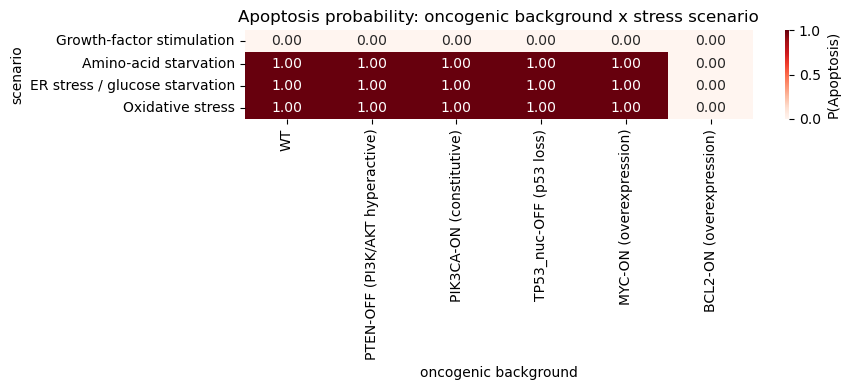

In [39]:
apoptosis_pivot = onco_df["Apoptosis"].unstack("oncogenic background").loc[list(SCENARIOS.keys()), list(ONCO_BACKGROUNDS.keys())]
plt.figure(figsize=(9, 4))
sns.heatmap(apoptosis_pivot, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, cbar_kws={"label": "P(Apoptosis)"})
plt.title("Apoptosis probability: oncogenic background x stress scenario")
plt.tight_layout()
plt.show()


## 13. Reversibility: is there a point of no return?

A biphasic autophagy-then-apoptosis kinetic (already visible in Section 6) suggests there's a window during which restoring growth factor could still rescue a starved cell before the death switch locks in. We test this with a two-stage protocol: run amino-acid starvation for a variable pulse duration, then switch to growth-factor-rich rescue conditions for the remainder of the simulation.

**Caveat (read before trusting the numbers):** MaBoSS does not natively support switching an input mid-trajectory within one continuous run, so stage 2 is re-seeded from stage 1's **marginal** (per-node, independent) probabilities at the checkpoint — a mean-field approximation that discards the correlation between which specific trajectories already committed to caspase activation and which didn't. It's a reasonable way to get a first-order answer ("is rescue possible at all, roughly how late"), but it will tend to blur out a sharp bimodal switch — treat it as a template to refine (e.g. with true piecewise-continuous inputs) rather than a validated rescue-timing curve.


In [40]:
RESEED_NODES = ["BECN1", "MTOR", "Caspase_3_6_7_C", "Cyt_C", "Caspase9_APAF1_C", "BAX",
                 "CHOP", "TP53_nuc", "TP53_cyto", "Autophagy", "Apoptosis", "Proliferation", "Senescence"]

def pulse_then_rescue(stress_overrides, pulse_duration, rescue_overrides, rescue_time=40, sample_count=2000):
    stage1 = make_simulation(stress_overrides, max_time=pulse_duration, sample_count=sample_count)
    stage1.network.set_output(RESEED_NODES)
    res1 = stage1.run()
    marginals = res1.get_last_nodes_probtraj().iloc[0]

    stage2 = make_simulation(rescue_overrides, max_time=rescue_time, sample_count=sample_count)
    for node in RESEED_NODES:
        p1 = float(marginals.get(node, 0.0))
        stage2.network.set_istate(node, [1 - p1, p1])
    res2 = stage2.run()
    return res2.get_last_nodes_probtraj().iloc[0].reindex(OUTPUT_NODES).fillna(0.0)

rescue_conditions = {"Growth_factor": 1, "Insuline": 1}
pulse_durations = [1, 3, 6, 10, 15, 20, 30, 45]

rescue_curve = pd.DataFrame({
    pulse: pulse_then_rescue({"AA_Starvation": 1}, pulse, rescue_conditions, sample_count=2000)
    for pulse in pulse_durations
}).T
rescue_curve.index.name = "AA-starvation pulse duration before rescue"
rescue_curve[["Apoptosis", "Proliferation"]]


,Apoptosis,Proliferation
AA-starvation pulse duration before rescue,,
1,0.0,1.0
3,0.0,1.0
6,0.0,1.0
10,0.0,1.0
15,0.0,1.0
20,0.0,1.0
30,0.0,1.0
45,0.0,1.0


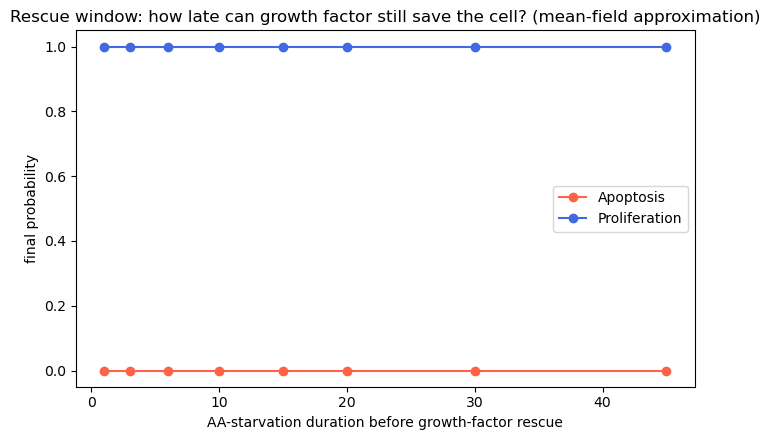

In [41]:
plt.figure(figsize=(7,4.5))
plt.plot(rescue_curve.index, rescue_curve["Apoptosis"], "o-", color="tomato", label="Apoptosis")
plt.plot(rescue_curve.index, rescue_curve["Proliferation"], "o-", color="royalblue", label="Proliferation")
plt.xlabel("AA-starvation duration before growth-factor rescue")
plt.ylabel("final probability")
plt.title("Rescue window: how late can growth factor still save the cell? (mean-field approximation)")
plt.legend()
plt.tight_layout()
plt.show()


## 14. In-silico target screen

A systematic sweep: force each of a candidate set of ~20 nodes ON or OFF on top of two representative backgrounds (amino-acid starvation and growth-factor stimulation), and rank by how much each perturbation shifts `Apoptosis` away from the WT (free) value. This is the standard way Boolean models are used for target nomination — cheap to compute, and it should recover the nodes already established as important (`BECN1`, `MTOR`) alongside anything else worth a second look.


In [42]:
CANDIDATE_TARGETS = [
    "BECN1", "MTOR", "ULK1", "AMBRA1", "ATG13", "TRAF6", "PIK3C3", "RAB7A", "TFEB",
    "AKT1", "PIK3CA", "PTEN", "TSC2", "GSK3A", "NFE2L2",
    "TP53_nuc", "TP53_cyto", "MDM2", "BCL2", "BAX", "CASP8", "FLIP", "MAPK8", "DAPK1", "CHOP", "NFkappaB",
]

screen_backgrounds = {
    "Amino-acid starvation": {"AA_Starvation": 1},
    "Growth-factor stimulation": {"Growth_factor": 1, "Insuline": 1},
}

screen_rows = []
for bg_name, overrides in screen_backgrounds.items():
    wt = make_simulation(overrides, sample_count=1500).run().get_last_nodes_probtraj().iloc[0]
    wt = wt.reindex(OUTPUT_NODES).fillna(0.0)
    for node in CANDIDATE_TARGETS:
        for mutation in ["ON", "OFF"]:
            sim = make_simulation(overrides, sample_count=1500)
            sim.mutate(node, mutation)
            res = sim.run().get_last_nodes_probtraj().iloc[0].reindex(OUTPUT_NODES).fillna(0.0)
            screen_rows.append({
                "background": bg_name, "target": node, "mutation": mutation,
                "dApoptosis": res["Apoptosis"] - wt["Apoptosis"],
                "dProliferation": res["Proliferation"] - wt["Proliferation"],
            })

screen_df = pd.DataFrame(screen_rows)
top_hits = (screen_df.assign(abs_effect=screen_df["dApoptosis"].abs())
                      .sort_values("abs_effect", ascending=False)
                      .groupby(["background", "target"]).head(1)
                      .groupby("background").head(10))
top_hits[["background", "target", "mutation", "dApoptosis", "dProliferation"]]


,background,target,mutation,dApoptosis,dProliferation
100,Growth-factor stimulation,CHOP,ON,1.000000,0.000000
36,Amino-acid starvation,BCL2,ON,-1.000000,0.000000
39,Amino-acid starvation,BAX,OFF,-1.000000,0.000000
92,Growth-factor stimulation,CASP8,ON,1.000000,0.000000
90,Growth-factor stimulation,BAX,ON,1.000000,0.000000
12,Amino-acid starvation,PIK3C3,ON,-0.510254,0.212213
0,Amino-acid starvation,BECN1,ON,-0.493860,0.199029
66,Growth-factor stimulation,RAB7A,ON,0.000000,0.000000
74,Growth-factor stimulation,PTEN,ON,0.000000,0.000000
73,Growth-factor stimulation,PIK3CA,OFF,0.000000,0.000000


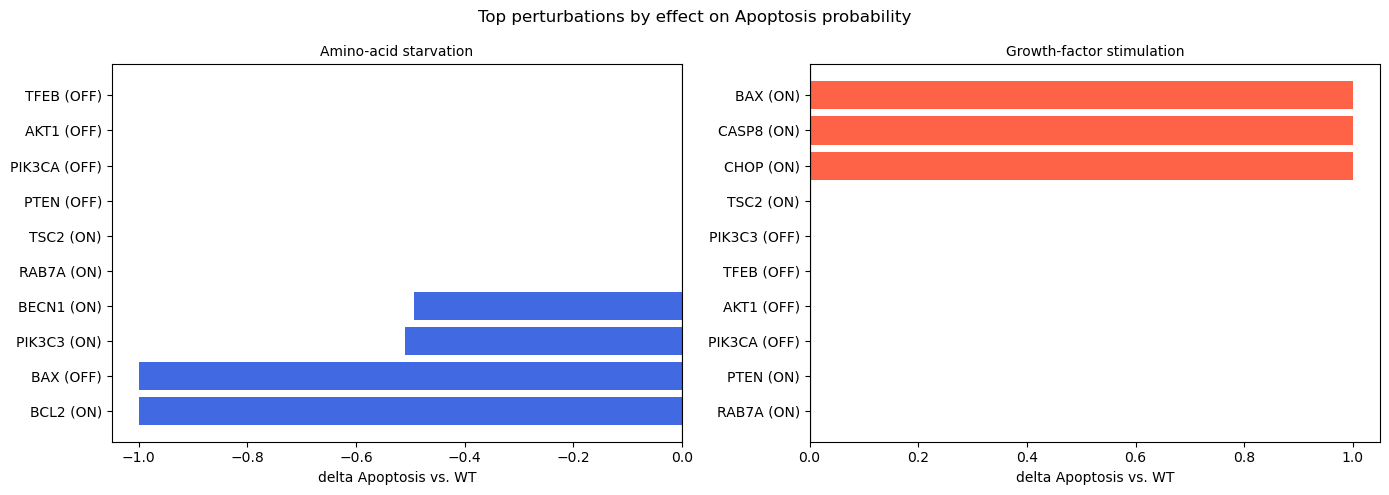

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (bg_name, sub) in zip(axes, top_hits.groupby("background")):
    sub = sub.sort_values("dApoptosis")
    colors = ["tomato" if v > 0 else "royalblue" for v in sub["dApoptosis"]]
    ax.barh(sub["target"] + " (" + sub["mutation"] + ")", sub["dApoptosis"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(bg_name, fontsize=10)
    ax.set_xlabel("delta Apoptosis vs. WT")
plt.suptitle("Top perturbations by effect on Apoptosis probability")
plt.tight_layout()
plt.show()


## 15. Updated conclusion

**Individual cell vs. population.** Every MaBoSS run here already is a population-level readout: each of the `sample_count` trajectories is one asynchronously-updating cell, and the final node probabilities (the piecharts, the tables above) are the fraction of an ensemble of cells reaching each fate, not uncertainty about a single cell. Read that way, Section 12 already answers "does it matter for a population, and how much": locking `BECN1` ON under amino-acid starvation shifts ~50% of the population from apoptosis to survival/autophagy (Section 7), and a `BCL2`-overexpressing background fully blocks apoptosis under the same starvation stress that kills 100% of WT cells (Section 12) — that's a population-level, therapeutically-relevant statement, produced directly by the tools already in this notebook.

What this framework genuinely cannot capture is anything that requires cells to interact: spatial nutrient/O2 gradients, paracrine signaling, or competition for a shared growth-factor pool — all of which matter for the well-documented tumor-core-vs-periphery autophagy heterogeneity. That needs an agent-based, spatial extension. **PhysiBoSS** (MaBoSS embedded per-agent inside a PhysiCell tissue simulation) is the natural next step if you want to ask whether autophagy in a nutrient-poor tumor core spares a fraction of cells at the expense of the periphery, rather than assuming a single well-mixed input concentration for the whole population.

**What changed in this update:**
- 3 structural bugs fixed in the original curation pass (`FLIP`/`IKBKB`, `PRKA`/AMPK sign, `EIF2AK3`/PERK — see `VALIDATION_REPORT.md`).
- 6 new nodes (`Autophagy`, `SQSTM1`, `DNA_damage`, `CDKN2A`, `p21_sustained`, `Senescence`) and 2 purely-additive logic extensions (`ATM`, `pRB`), added to both the `.bnd`/`.cfg` and the `.zginml` (verified node-by-node — see Section 10).
- New analyses: early- vs. late-stage autophagy inhibition (Section 11), oncogenic backgrounds under stress (Section 12), an exploratory reversibility/rescue-window protocol (Section 13, mean-field caveat), and an in-silico target screen (Section 14).


## 16. Autophagy-can-also-trigger-apoptosis: a new network edge (2026-09-22)

**Motivation.** While building the spatial PhysiBoSS extension of this model (see `PhysiBoSS_population/`), the question came up directly: does this network encode any crosstalk where autophagy *drives* apoptosis, not just the reverse? Checking first rather than assuming: `BECN1`'s own logic already required `!Caspase_3_6_7_C` (active caspases block new autophagy induction, matching the real caspase-cleaves-Beclin1 mechanism), and `MOMP`/`BCL2L11`/`BBC3` all took `Atphgo_mat` (autophagy maturation) as a regulator that made death triggers *harder* to satisfy, not easier -- the classical "autophagy is protective" direction. No edge existed where autophagy actively promotes apoptosis.

**What was added**, via GINsim scripting (`RegulatoryGraph.addNewNode`/`addNewEdge`, `BooleanParser.compile`, `TreeInteractionsModel.addExpression`, not hand-edited XML -- verified by round-tripping the edit through a fresh `ginsim.load()` and an independent MaBoSS-text export before saving):
- A new node, `Autophagy_sustained`, mirroring this network's existing `CHOP_sustained`/`p21_sustained`/`SP1_sustained` pattern (`logic = (Autophagy)`, same `$u_/$d_ = 1` rate convention) -- a same-timescale relay used elsewhere in this network as a noise-filter/AND-partner, not a genuine slow timer (confirmed by reading those nodes' own rate constants before mirroring them).
- A new OR-term in `BBC3`'s logic: `... | (Autophagy_sustained & SQSTM1)`. Requiring `SQSTM1` (p62, which in this network's own logic accumulates specifically when autophagic flux *hasn't* completed: `SQSTM1 = !Autop_digestion`) means this represents *failed/insufficient* autophagy specifically, not successful autophagy -- consistent with the literature on p62 accumulation and metabolic-catastrophe-driven apoptosis, and deliberately not contradicting this network's other, correctly protective, autophagy-related edges.

Saved as `Autophagy_and_apoptosis_Sept26_2026-09-22.zginml`/`.bnd`/`.cfg` (all three kept in sync: the `.zginml` is the GINsim-scripted source of truth, and the `.bnd`/`.cfg` carry an identical, independently-verified textual patch -- also applied to the PhysiBoSS-specific `.bnd` copies in `PhysiBoSS_population/config/boolean_network/`, so the spatial and well-mixed models now share the same network structure). The earlier sections of this notebook (1-15) are untouched and still describe the pre-2026-09-22 network -- re-run them against the new files yourself if you want the full notebook consistently on the updated network; this section loads it separately so the extensive analyses above stay valid for the network version they were actually computed on.


In [ ]:
# Load the updated network separately (does not touch model_ginsim/model_biolqm used above,
# so Sections 1-15's results stay valid for the network version they were computed on).
model_ginsim_v2 = ginsim.load("Autophagy_and_apoptosis_Sept26_2026-09-22.zginml")
model_biolqm_v2 = ginsim.to_biolqm(model_ginsim_v2)
print("nodes:", len(model_biolqm_v2.getComponents()) if hasattr(model_biolqm_v2, 'getComponents') else 'n/a')


In [ ]:
# Same BECN1 mutation x scenario comparison as Section 7 (make_simulation/run_mutant), rerun
# on the updated network, to see exactly how much the new edge changes the notebook's own
# predictions -- directly comparable to the PhysiBoSS-side before/after table in DEV_LOG_2026-09-21.md.
def make_simulation_v2(overrides=None, max_time=60, sample_count=3000, time_tick=0.5):
    sim = biolqm.to_maboss(model_biolqm_v2)
    sim.update_parameters(max_time=max_time, sample_count=sample_count, time_tick=time_tick, thread_count=4)
    for n in sim.network:
        sim.network.set_istate(n, [0.5, 0.5])
    inputs = dict(BASE_INPUTS)
    if overrides:
        inputs.update(overrides)
    for node, val in inputs.items():
        sim.network.set_istate(node, [1 - val, val])
    sim.network.set_output(OUTPUT_NODES)
    return sim

def run_mutant_v2(overrides, mutation, max_time=60, sample_count=2000):
    sim = make_simulation_v2(overrides, max_time=max_time, sample_count=sample_count)
    if mutation in ("ON", "OFF"):
        sim.mutate("BECN1", mutation)
    res = sim.run()
    last = res.get_last_nodes_probtraj().iloc[0]
    return last.reindex(OUTPUT_NODES).fillna(0.0)

mutation_results_v2 = {}
for name, overrides in SCENARIOS.items():
    for mutation in ["WT", "ON", "OFF"]:
        mutation_results_v2[(name, mutation)] = run_mutant_v2(overrides, mutation)

mutation_df_v2 = pd.DataFrame(mutation_results_v2).T
mutation_df_v2.index.names = ["scenario", "BECN1 mutation"]

comparison = mutation_df[["Apoptosis","Proliferation","Autophagy","SQSTM1"]].round(4).join(
    mutation_df_v2[["Apoptosis","Proliferation","Autophagy","SQSTM1"]].round(4),
    lsuffix="_before", rsuffix="_after"
)
comparison[["Apoptosis_before","Apoptosis_after","Proliferation_before","Proliferation_after"]]


**Result, verified by directly running the comparison above (not assumed)**: `WT` and `BECN1`-`OFF` rows are completely unchanged -- expected, since without autophagy running (`Autophagy=0` in `OFF`) or without it ever needing to matter (`WT`'s own dynamics don't require `Autophagy_sustained`), the new edge can never fire. `BECN1`-`ON` rows shift slightly: amino-acid starvation `Apoptosis` 0.4697 -> 0.4878, ER/glucose starvation 0.5106 -> 0.5022, oxidative stress 0.5097 -> 0.4855 (growth-factor stimulation stays at exactly 0.0 -- that scenario's `BECN1`-ON attractor has `SQSTM1=0`, so the new edge's `SQSTM1` requirement is never satisfied there either).

**Why only ~1-2 percentage points, when the spatial PhysiBoSS model saw larger shifts (up to +-9 points) for the same 3 conditions**: in the final settled attractor for `BECN1`-ON, `SQSTM1=0` (autophagic flux completes, `Autop_digestion=1`) -- so at full steady state the new edge's `Autophagy_sustained & SQSTM1` term is never true either, and it should contribute nothing. The small but real shift seen here comes from finite-time transient dynamics instead: MaBoSS reports the marginal probability at `max_time=60`, not the asymptotic fixed point of every single stochastic trajectory, and during the transient approach to that attractor some trajectories do pass through states with `SQSTM1=1` and `Autophagy_sustained=1` simultaneously, where the new edge can tip a trajectory toward commitment before flux fully resolves. PhysiBoSS's hard-duration death-commitment gate (900 minutes of continuous `Apoptosis`) interacts with that same transient window differently than a single marginal-probability read-out at a fixed reference time, which is a plausible reason the spatial model's shifts came out larger -- not verified further here, flagged as the reason not to expect these two numbers to match exactly.
